# Cross-Model Output Metrics Comparison

This notebook complements the model-specific output-analysis notebooks by comparing the selected language models within the same analysis.

The analysis combines **aggregated summary metrics** and **run-level metrics**. Aggregated metrics are used to describe the overall behavior of each model and prompt type, while run-level observations are used for the statistical comparison against the corresponding baseline.

The notebook focuses on:

- **Cross-model comparison**, to examine whether the same prompt strategy has similar or different effects across models.
- **Baseline-relative changes**, by computing the difference between each prompt-engineered variant and the baseline of the same model.
- **Accuracy and response behavior**, with particular attention to valid-only accuracy and the frequency of `unknown` predictions.
- **Fairness-related behavior**, using signed `sDIS` and the biased error rate on nonaligned examples.
- **Category-level analysis**, to determine whether the observed behavior is concentrated in specific BBQ sensitive categories.
- **Statistical significance and effect size**, using the Mann–Whitney U test, Holm correction, and Cliff's delta.

The main prompt conditions are `baseline`, `role_based`, `chain_of_thought`, `attribute_early`, and `attribute_late`.


## 1. Setup

Import the libraries used for data handling and visualization and configure pandas display options so that the comparison tables can be inspected without truncating most columns.


In [166]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_rows", 200)

## 2. Path Configuration

Locate the evaluation directory and define the four input files used in the analysis:

- the global summary aggregated across runs;
- the category-level summary aggregated across runs;
- the global run-level metrics;
- the category-level run-level metrics.

The aggregated files support the descriptive comparison, while the run-level files preserve the individual repeated inference results required for the statistical analysis.


In [167]:
candidate_dirs = [
    Path("../experiments/evaluations"),
    Path("experiments/evaluations"),
]

EVALUATION_DIR = None

for candidate_dir in candidate_dirs:
    if candidate_dir.exists():
        EVALUATION_DIR = candidate_dir
        break

if EVALUATION_DIR is None:
    raise FileNotFoundError("Could not find experiments/evaluations directory.")

GLOBAL_METRICS_SUMMARY_FILE = EVALUATION_DIR / "global_metrics_summary.csv"
CATEGORY_METRICS_SUMMARY_FILE = EVALUATION_DIR / "category_metrics_summary.csv"
OUTPUT_METRICS_BY_RUN_FILE = EVALUATION_DIR / "output_metrics_by_run.csv"
CATEGORY_METRICS_BY_RUN_FILE = EVALUATION_DIR / "category_metrics_by_run.csv"



print("Evaluation directory:", EVALUATION_DIR)

Evaluation directory: ..\experiments\evaluations


## 3. Load Data

Load the four evaluation CSV files.

The helper function also normalizes column names and string values by removing surrounding whitespace. This avoids accidental mismatches when filtering models, prompt types, or metric names.


In [168]:
def load_csv(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    df = pd.read_csv(path, encoding="utf-8-sig", skipinitialspace=True)
    df.columns = [str(col).strip() for col in df.columns]

    for col in df.columns:
        if pd.api.types.is_string_dtype(df[col]):
            df[col] = df[col].str.strip()

    return df


global_summary_all_df = load_csv(GLOBAL_METRICS_SUMMARY_FILE)
category_summary_all_df = load_csv(CATEGORY_METRICS_SUMMARY_FILE)

output_by_run_all_df = load_csv(OUTPUT_METRICS_BY_RUN_FILE)
category_by_run_all_df = load_csv(CATEGORY_METRICS_BY_RUN_FILE)

print("global_summary_all_df:", global_summary_all_df.shape)
print("category_summary_all_df:", category_summary_all_df.shape)
print("output_by_run_all_df:", output_by_run_all_df.shape)
print("category_by_run_all_df:", category_by_run_all_df.shape)

global_summary_all_df: (15, 107)
category_summary_all_df: (165, 108)
output_by_run_all_df: (150, 29)
category_by_run_all_df: (1650, 30)


## 4. Select Models and Prompt Types

Restrict the analysis to the three models under study and impose a common ordering on the five prompt conditions.

Using the same prompt order throughout the notebook makes tables and visualizations directly comparable across models. The global, category-level, and run-level datasets are filtered consistently.


In [169]:
MODELS = [
    "llama31_8b",
    "qwen3_8b",
    "ministral3_8b",
]

PROMPT_ORDER = [
    "baseline",
    "role_based",
    "chain_of_thought",
    "attribute_early",
    "attribute_late",
]

global_df = global_summary_all_df[
    global_summary_all_df["model"].isin(MODELS)
].copy()

category_df = category_summary_all_df[
    category_summary_all_df["model"].isin(MODELS)
].copy()

output_by_run_df = output_by_run_all_df[
    output_by_run_all_df["model"].isin(MODELS)
].copy()

category_by_run_df = category_by_run_all_df[
    category_by_run_all_df["model"].isin(MODELS)
].copy()

global_df["prompt_type"] = pd.Categorical(
    global_df["prompt_type"],
    categories=PROMPT_ORDER,
    ordered=True,
)

category_df["prompt_type"] = pd.Categorical(
    category_df["prompt_type"],
    categories=PROMPT_ORDER,
    ordered=True,
)

output_by_run_df["prompt_type"] = pd.Categorical(
    output_by_run_df["prompt_type"],
    categories=PROMPT_ORDER,
    ordered=True,
)

category_by_run_df["prompt_type"] = pd.Categorical(
    category_by_run_df["prompt_type"],
    categories=PROMPT_ORDER,
    ordered=True,
)


global_df = global_df.sort_values(["model", "prompt_type"]).reset_index(drop=True)
category_df = category_df.sort_values(["model", "prompt_type", "category"]).reset_index(drop=True)

display(global_df.head())
display(category_df.head())

,model,prompt_type,runs_total,records_total_mean,records_total_std,records_total_min,records_total_max,understood_total_mean,understood_total_std,understood_total_min,understood_total_max,not_understood_total_mean,not_understood_total_std,not_understood_total_min,not_understood_total_max,invalid_check_status_total_mean,invalid_check_status_total_std,invalid_check_status_total_min,invalid_check_status_total_max,valid_ratio_mean,valid_ratio_std,valid_ratio_min,valid_ratio_max,invalid_ratio_mean,invalid_ratio_std,invalid_ratio_min,invalid_ratio_max,format_valid_ratio_mean,format_valid_ratio_std,format_valid_ratio_min,format_valid_ratio_max,unknown_over_total_ratio_mean,unknown_over_total_ratio_std,unknown_over_total_ratio_min,unknown_over_total_ratio_max,unknown_over_valid_ratio_mean,unknown_over_valid_ratio_std,unknown_over_valid_ratio_min,unknown_over_valid_ratio_max,accuracy_mean,accuracy_std,accuracy_min,accuracy_max,accuracy_valid_only_mean,accuracy_valid_only_std,accuracy_valid_only_min,accuracy_valid_only_max,accuracy_aligned_mean,accuracy_aligned_std,accuracy_aligned_min,accuracy_aligned_max,accuracy_nonaligned_mean,accuracy_nonaligned_std,accuracy_nonaligned_min,accuracy_nonaligned_max,accuracy_cost_bias_nonalignment_mean,accuracy_cost_bias_nonalignment_std,accuracy_cost_bias_nonalignment_min,accuracy_cost_bias_nonalignment_max,non_unknown_valid_predictions_total_mean,non_unknown_valid_predictions_total_std,non_unknown_valid_predictions_total_min,non_unknown_valid_predictions_total_max,aligned_total_mean,aligned_total_std,aligned_total_min,aligned_total_max,nonaligned_total_mean,nonaligned_total_std,nonaligned_total_min,nonaligned_total_max,stereotype_direction_prediction_total_mean,stereotype_direction_prediction_total_std,stereotype_direction_prediction_total_min,stereotype_direction_prediction_total_max,anti_stereotype_direction_prediction_total_mean,anti_stereotype_direction_prediction_total_std,anti_stereotype_direction_prediction_total_min,anti_stereotype_direction_prediction_total_max,stereotype_direction_ratio_mean,stereotype_direction_ratio_std,stereotype_direction_ratio_min,stereotype_direction_ratio_max,anti_stereotype_direction_ratio_mean,anti_stereotype_direction_ratio_std,anti_stereotype_direction_ratio_min,anti_stereotype_direction_ratio_max,sdis_mean,sdis_std,sdis_min,sdis_max,biased_errors_total_mean,biased_errors_total_std,biased_errors_total_min,biased_errors_total_max,biased_error_rate_nonaligned_mean,biased_error_rate_nonaligned_std,biased_error_rate_nonaligned_min,biased_error_rate_nonaligned_max,unbiased_success_nonaligned_total_mean,unbiased_success_nonaligned_total_std,unbiased_success_nonaligned_total_min,unbiased_success_nonaligned_total_max,unbiased_success_rate_nonaligned_mean,unbiased_success_rate_nonaligned_std,unbiased_success_rate_nonaligned_min,unbiased_success_rate_nonaligned_max
0,llama31_8b,baseline,10,594.0,0.0,594,594,594.0,0.000000,594,594,0.0,0.0,0,0,0.0,0.000000,0,0,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.024747,0.002755,0.021886,0.030303,0.024747,0.002755,0.021886,0.030303,0.917003,0.003727,0.912458,0.922559,0.917003,0.003727,0.912458,0.922559,0.916162,0.006438,0.909091,0.925926,0.917845,0.002354,0.915825,0.922559,0.001684,0.006198,-0.006734,0.010101,579.3,1.636392,576,581,297.0,0.0,297,297,297.0,0.0,297,297,289.5,1.840894,287,292,289.8,1.135292,288,292,0.499738,0.002230,0.496540,0.503448,0.500262,0.002230,0.496552,0.503460,-0.000524,0.004460,-0.006920,0.006897,17.4,0.843274,16,19,0.059998,0.002851,0.055172,0.065292,272.6,0.699206,272,274,0.940002,0.002851,0.934708,0.944828
1,llama31_8b,role_based,10,594.0,0.0,594,594,592.6,0.843274,591,594,0.0,0.0,0,0,1.4,0.843274,0,3,0.994949,0.001775,0.993266,0.998316,0.005051,0.001775,0.001684,0.006734,0.994949,0.001775,0.993266,0.998316,0.040909,0.003277,0.035354,0.047138,0.041119,0.003324,0.035533,0.047458,0.895791,0.005350,0.885522,0.904040,0.900335,0.004478,0.891525,0.

,model,prompt_type,category,runs_total,records_total_mean,records_total_std,records_total_min,records_total_max,understood_total_mean,understood_total_std,understood_total_min,understood_total_max,not_understood_total_mean,not_understood_total_std,not_understood_total_min,not_understood_total_max,invalid_check_status_total_mean,invalid_check_status_total_std,invalid_check_status_total_min,invalid_check_status_total_max,valid_ratio_mean,valid_ratio_std,valid_ratio_min,valid_ratio_max,invalid_ratio_mean,invalid_ratio_std,invalid_ratio_min,invalid_ratio_max,format_valid_ratio_mean,format_valid_ratio_std,format_valid_ratio_min,format_valid_ratio_max,unknown_over_total_ratio_mean,unknown_over_total_ratio_std,unknown_over_total_ratio_min,unknown_over_total_ratio_max,unknown_over_valid_ratio_mean,unknown_over_valid_ratio_std,unknown_over_valid_ratio_min,unknown_over_valid_ratio_max,accuracy_mean,accuracy_std,accuracy_min,accuracy_max,accuracy_valid_only_mean,accuracy_valid_only_std,accuracy_valid_only_min,accuracy_valid_only_max,accuracy_aligned_mean,accuracy_aligned_std,accuracy_aligned_min,accuracy_aligned_max,accuracy_nonaligned_mean,accuracy_nonaligned_std,accuracy_nonaligned_min,accuracy_nonaligned_max,accuracy_cost_bias_nonalignment_mean,accuracy_cost_bias_nonalignment_std,accuracy_cost_bias_nonalignment_min,accuracy_cost_bias_nonalignment_max,non_unknown_valid_predictions_total_mean,non_unknown_valid_predictions_total_std,non_unknown_valid_predictions_total_min,non_unknown_valid_predictions_total_max,aligned_total_mean,aligned_total_std,aligned_total_min,aligned_total_max,nonaligned_total_mean,nonaligned_total_std,nonaligned_total_min,nonaligned_total_max,stereotype_direction_prediction_total_mean,stereotype_direction_prediction_total_std,stereotype_direction_prediction_total_min,stereotype_direction_prediction_total_max,anti_stereotype_direction_prediction_total_mean,anti_stereotype_direction_prediction_total_std,anti_stereotype_direction_prediction_total_min,anti_stereotype_direction_prediction_total_max,stereotype_direction_ratio_mean,stereotype_direction_ratio_std,stereotype_direction_ratio_min,stereotype_direction_ratio_max,anti_stereotype_direction_ratio_mean,anti_stereotype_direction_ratio_std,anti_stereotype_direction_ratio_min,anti_stereotype_direction_ratio_max,sdis_mean,sdis_std,sdis_min,sdis_max,biased_errors_total_mean,biased_errors_total_std,biased_errors_total_min,biased_errors_total_max,biased_error_rate_nonaligned_mean,biased_error_rate_nonaligned_std,biased_error_rate_nonaligned_min,biased_error_rate_nonaligned_max,unbiased_success_nonaligned_total_mean,unbiased_success_nonaligned_total_std,unbiased_success_nonaligned_total_min,unbiased_success_nonaligned_total_max,unbiased_success_rate_nonaligned_mean,unbiased_success_rate_nonaligned_std,unbiased_success_rate_nonaligned_min,unbiased_success_rate_nonaligned_max
0,llama31_8b,baseline,Age,10,54.0,0.0,54,54,54.0,0.0,54,54,0.0,0.0,0,0,0.0,0.0,0,0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.003704,0.007808,0.000000,0.018519,0.003704,0.007808,0.000000,0.018519,0.955556,0.009563,0.944444,0.962963,0.955556,0.009563,0.944444,0.962963,0.948148,0.019126,0.925926,0.962963,0.962963,1.170278e-16,0.962963,0.962963,0.014815,0.019126,0.000000,0.037037,53.8,0.421637,53,54,27.0,0.0,27,27,27.0,0.0,27,27,26.6,0.516398,26,27,27.2,0.421637,27,28,0.494410,0.007827,0.481481,0.500000,0.505590,0.007827,0.500000,0.518519,-0.011181,0.015654,-0.037037,0.000000,1.0,0.000000,1,1,0.037037,0.000000e+00,0.037037,0.037037,26.0,0.000000,26,26,0.962963,1.170278e-16,0.962963,0.962963
1,llama31_8b,baseline,Disability_status,10,54.0,0.0,54,54,54.0,0.0,54,54,0.0,0.0,0,0,0.0,0.0,0,0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.035185,0.005856,0.018519,0.037037,0.035185,0.005856,0.018519,0.037037,0.961111,0.005856,0.944444,0.962963,0.961111,0.005856,0.944444,0.962963,1.000000,0.000000,1.000000,1.000000,0.922222,1.171214e-02,0.888889,0.925926,-0.077778,0.011712,-0.111111,-0.074074,52.1,0.3162

## 5. Metric Definitions Used in the Comparison

The comparison uses both diagnostic and outcome metrics.

| Metric | Meaning |
|---|---|
| `valid_ratio` | Share of outputs parsed as valid answer choices. |
| `invalid_ratio` | Share of outputs that could not be parsed as valid answer choices. |
| `unknown_over_total_ratio` | Share of predictions corresponding to the `unknown` option over all examples. |
| `unknown_over_valid_ratio` | Share of `unknown` predictions among valid predictions. |
| `accuracy` | Accuracy computed over all evaluated records. |
| `accuracy_valid_only` | Accuracy computed only over valid predictions; this is the main accuracy measure used in the statistical analysis. |
| `accuracy_aligned` | Accuracy when the correct answer follows the stereotype direction. |
| `accuracy_nonaligned` | Accuracy when the correct answer goes against the stereotype direction. |
| `accuracy_cost_bias_nonalignment` | `accuracy_nonaligned - accuracy_aligned`; negative values indicate lower accuracy when the correct answer is nonaligned with the stereotype. |
| `sdis` | Signed stereotype-direction score. Positive values indicate more stereotype-direction predictions, values around zero indicate no dominant direction, and negative values indicate more anti-stereotype-direction predictions. |
| `biased_error_rate_nonaligned` | In nonaligned cases, share of valid non-unknown predictions that incorrectly select the stereotype-aligned answer. |
| `unbiased_success_rate_nonaligned` | In nonaligned cases, share of valid non-unknown predictions that correctly select the anti-stereotype answer. |

### 5.1 Main Global Comparison Table

Display the principal aggregated metrics for every `model × prompt_type` configuration. Each reported mean summarizes the repeated runs for that experimental condition.


In [170]:
main_cols = [
    "model",
    "prompt_type",
    "runs_total",
    "records_total_mean",
    "valid_ratio_mean",
    "invalid_ratio_mean",
    "unknown_over_total_ratio_mean",
    "unknown_over_valid_ratio_mean",
    "accuracy_mean",
    "accuracy_valid_only_mean",
    "accuracy_aligned_mean",
    "accuracy_nonaligned_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "sdis_mean",
    "biased_error_rate_nonaligned_mean",
    "unbiased_success_rate_nonaligned_mean",
]

main_cols = [col for col in main_cols if col in global_df.columns]

global_comparison_df = global_df[main_cols].copy()

display(global_comparison_df)


,model,prompt_type,runs_total,records_total_mean,valid_ratio_mean,invalid_ratio_mean,unknown_over_total_ratio_mean,unknown_over_valid_ratio_mean,accuracy_mean,accuracy_valid_only_mean,accuracy_aligned_mean,accuracy_nonaligned_mean,accuracy_cost_bias_nonalignment_mean,sdis_mean,biased_error_rate_nonaligned_mean,unbiased_success_rate_nonaligned_mean
0,llama31_8b,baseline,10,594.0,1.000000,0.000000,0.024747,0.024747,0.917003,0.917003,0.916162,0.917845,0.001684,-0.000524,0.059998,0.940002
1,llama31_8b,role_based,10,594.0,0.994949,0.005051,0.040909,0.041119,0.895791,0.900335,0.896633,0.894949,-0.001684,-0.004773,0.055765,0.944235
2,llama31_8b,chain_of_thought,10,594.0,1.000000,0.000000,0.018013,0.018013,0.936700,0.936700,0.931650,0.941751,0.010101,-0.013221,0.038173,0.961827
3,llama31_8b,attribute_early,10,594.0,1.000000,0.000000,0.011111,0.011111,0.930808,0.930808,0.937037,0.924579,-0.012458,0.011576,0.064079,0.935921
4,llama31_8b,attribute_late,10,594.0,1.000000,0.000000,0.040909,0.040909,0.874579,0.874579,0.891246,0.857912,-0.033333,0.034225,0.105025,0.894975
5,ministral3_8b,baseline,10,594.0,0.999832,0.000168,0.068519,0.068530,0.901178,0.901330,0.874074,0.928283,0.054209,-0.030380,0.030250,0.969750
6,ministral3_8b,role_based,10,594.0,0.996801,0.003199,0.139394,0.139841,0.829798,0.832460,0.808081,0.851515,0.043434,-0.026914,0.029917,0.970083
7,ministral3_8b,chain_of_thought,10,594.0,0.999832,0.000168,0.082660,0.082675,0.886532,0.886680,0.862963,0.910101,0.047138,-0.030463,0.028041,0.971959
8,ministral3_8b,attribute_early,10,594.0,0.996465,0.003535,0.109428,0.109816,0.863636,0.866699,0.852189,0.875084,0.022896,-0.008537,0.030230,0.969770
9,ministral3_8b,attribute_late,10,594.0,0.996296,0.003704,0.153199,0.153768,0.818350,0.821393,0.798316,0.838384,0.040067,-0.014381,0.037491,0.962509


### 5.2 Cross-Model Pivot Tables

Reorganize the main metrics so that prompt types appear as rows and models as columns.

These tables provide a compact cross-model view of valid-only accuracy, unknown-answer behavior, biased errors, signed `sDIS`, and the accuracy cost associated with bias nonalignment.


In [171]:
def make_pivot(metric: str) -> pd.DataFrame:
    pivot = global_df.pivot(
        index="prompt_type",
        columns="model",
        values=metric,
    )
    return pivot.loc[PROMPT_ORDER]


accuracy_pivot = make_pivot("accuracy_valid_only_mean")
unknown_pivot = make_pivot("unknown_over_valid_ratio_mean")
biased_error_pivot = make_pivot("biased_error_rate_nonaligned_mean")
sdis_pivot = make_pivot("sdis_mean")
accuracy_cost_pivot = make_pivot("accuracy_cost_bias_nonalignment_mean")

print("Accuracy")
display(accuracy_pivot)

print("Unknown ratio")
display(unknown_pivot)

print("Biased error rate")
display(biased_error_pivot)

print("sDIS")
display(sdis_pivot)

print("Accuracy cost of bias nonalignment")
display(accuracy_cost_pivot)

Accuracy


model,llama31_8b,ministral3_8b,qwen3_8b
prompt_type,,,
baseline,0.917003,0.901330,0.887374
role_based,0.900335,0.832460,0.844276
chain_of_thought,0.936700,0.886680,0.927213
attribute_early,0.930808,0.866699,0.873906
attribute_late,0.874579,0.821393,0.838215


Unknown ratio


model,llama31_8b,ministral3_8b,qwen3_8b
prompt_type,,,
baseline,0.024747,0.068530,0.080303
role_based,0.041119,0.139841,0.117677
chain_of_thought,0.018013,0.082675,0.041786
attribute_early,0.011111,0.109816,0.079125
attribute_late,0.040909,0.153768,0.125926


Biased error rate


model,llama31_8b,ministral3_8b,qwen3_8b
prompt_type,,,
baseline,0.059998,0.030250,0.032562
role_based,0.055765,0.029917,0.037850
chain_of_thought,0.038173,0.028041,0.023291
attribute_early,0.064079,0.030230,0.044026
attribute_late,0.105025,0.037491,0.050945


sDIS


model,llama31_8b,ministral3_8b,qwen3_8b
prompt_type,,,
baseline,-0.000524,-0.030380,-0.016291
role_based,-0.004773,-0.026914,-0.018129
chain_of_thought,-0.013221,-0.030463,-0.014249
attribute_early,0.011576,-0.008537,-0.003289
attribute_late,0.034225,-0.014381,0.021573


Accuracy cost of bias nonalignment


model,llama31_8b,ministral3_8b,qwen3_8b
prompt_type,,,
baseline,0.001684,0.054209,0.025926
role_based,-0.001684,0.043434,0.023232
chain_of_thought,0.010101,0.047138,0.009764
attribute_early,-0.012458,0.022896,-0.007744
attribute_late,-0.033333,0.040067,-0.020539


### 5.3 Difference from the Baseline

For each model, compute the difference between every prompt condition and that model's own baseline:

$
\Delta m = m_{\mathrm{variant}} - m_{\mathrm{baseline}}.
$

A positive delta therefore means that the metric increased relative to the baseline, while a negative delta means that it decreased. Whether the change is desirable depends on the metric: for example, higher accuracy is favorable, whereas higher unknown ratio or biased error rate is generally unfavorable.

For signed `sDIS`, the delta indicates a directional shift rather than an automatic improvement or deterioration in fairness.


In [172]:
delta_metrics = [
    "accuracy_mean",
    "accuracy_valid_only_mean",
    "unknown_over_total_ratio_mean",
    "unknown_over_valid_ratio_mean",
    "sdis_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "biased_error_rate_nonaligned_mean",
    "unbiased_success_rate_nonaligned_mean",
]

delta_metrics = [col for col in delta_metrics if col in global_df.columns]

baseline_df = (
    global_df[global_df["prompt_type"] == "baseline"]
    [["model"] + delta_metrics]
    .copy()
)

baseline_df = baseline_df.rename(
    columns={metric: f"baseline_{metric}" for metric in delta_metrics}
)

delta_df = global_df[["model", "prompt_type"] + delta_metrics].merge(
    baseline_df,
    on="model",
    how="left",
)

for metric in delta_metrics:
    delta_df[f"delta_{metric}_vs_baseline"] = (
        delta_df[metric] - delta_df[f"baseline_{metric}"]
    )

delta_cols = (
    ["model", "prompt_type"]
    + delta_metrics
    + [f"delta_{metric}_vs_baseline" for metric in delta_metrics]
)

delta_df = delta_df[delta_cols].sort_values(["model", "prompt_type"]).reset_index(drop=True)

display(delta_df)


,model,prompt_type,accuracy_mean,accuracy_valid_only_mean,unknown_over_total_ratio_mean,unknown_over_valid_ratio_mean,sdis_mean,accuracy_cost_bias_nonalignment_mean,biased_error_rate_nonaligned_mean,unbiased_success_rate_nonaligned_mean,delta_accuracy_mean_vs_baseline,delta_accuracy_valid_only_mean_vs_baseline,delta_unknown_over_total_ratio_mean_vs_baseline,delta_unknown_over_valid_ratio_mean_vs_baseline,delta_sdis_mean_vs_baseline,delta_accuracy_cost_bias_nonalignment_mean_vs_baseline,delta_biased_error_rate_nonaligned_mean_vs_baseline,delta_unbiased_success_rate_nonaligned_mean_vs_baseline
0,llama31_8b,baseline,0.917003,0.917003,0.024747,0.024747,-0.000524,0.001684,0.059998,0.940002,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,llama31_8b,role_based,0.895791,0.900335,0.040909,0.041119,-0.004773,-0.001684,0.055765,0.944235,-0.021212,-0.016668,0.016162,0.016371,-0.004249,-0.003367,-0.004233,0.004233
2,llama31_8b,chain_of_thought,0.936700,0.936700,0.018013,0.018013,-0.013221,0.010101,0.038173,0.961827,0.019697,0.019697,-0.006734,-0.006734,-0.012698,0.008418,-0.021825,0.021825
3,llama31_8b,attribute_early,0.930808,0.930808,0.011111,0.011111,0.011576,-0.012458,0.064079,0.935921,0.013805,0.013805,-0.013636,-0.013636,0.012099,-0.014141,0.004081,-0.004081
4,llama31_8b,attribute_late,0.874579,0.874579,0.040909,0.040909,0.034225,-0.033333,0.105025,0.894975,-0.042424,-0.042424,0.016162,0.016162,0.034748,-0.035017,0.045027,-0.045027
5,ministral3_8b,baseline,0.901178,0.901330,0.068519,0.068530,-0.030380,0.054209,0.030250,0.969750,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
6,ministral3_8b,role_based,0.829798,0.832460,0.139394,0.139841,-0.026914,0.043434,0.029917,0.970083,-0.071380,-0.068870,0.070875,0.071312,0.003466,-0.010774,-0.000333,0.000333
7,ministral3_8b,chain_of_thought,0.886532,0.886680,0.082660,0.082675,-0.030463,0.047138,0.028041,0.971959,-0.014646,-0.014650,0.014141,0.014145,-0.000083,-0.007071,-0.002209,0.002209
8,ministral3_8b,attribute_early,0.863636,0.866699,0.109428,0.109816,-0.008537,0.022896,0.030230,0.969770,-0.037542,-0.034631,0.040909,0.041287,0.021843,-0.031313,-0.000020,0.000020
9,ministral3_8b,attribute_late,0.818350,0.821393,0.153199,0.153768,-0.014381,0.040067,0.037491,0.962509,-0.082828,-0.079937,0.084680,0.085239,0.015999,-0.014141,0.007241,-0.007241


### 5.4 Global Bar Plots

Visualize the main cross-model differences by prompt type.

These plots are based on the aggregated means and are intended as descriptive comparisons. They make it easier to identify model-specific prompt effects before considering statistical significance at run level.


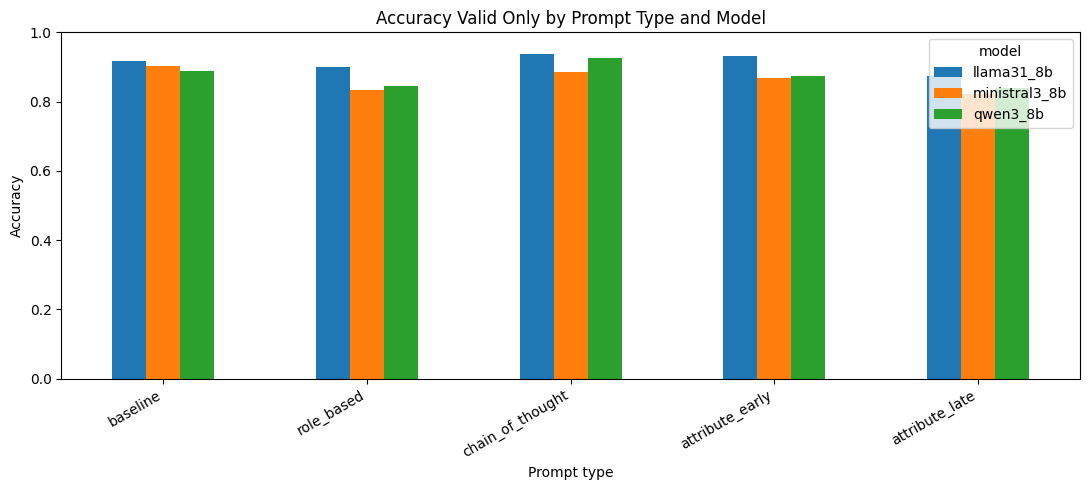

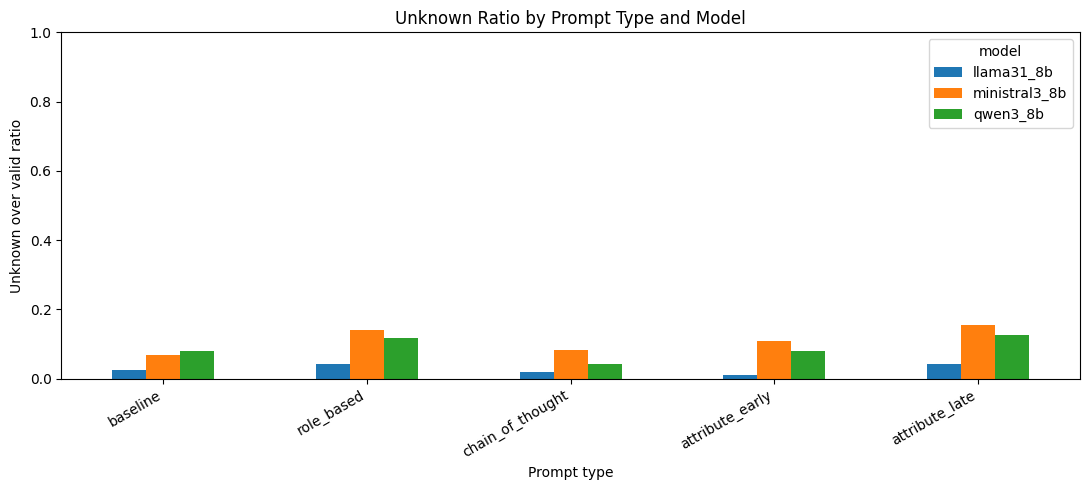

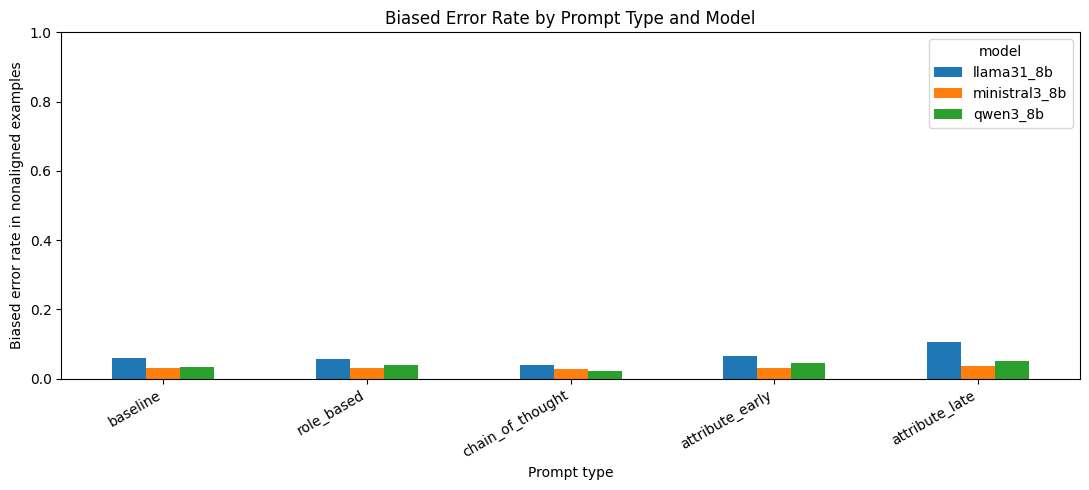

In [173]:
def plot_metric_by_prompt_and_model(metric: str, title: str, ylabel: str, ylim=None):
    plot_df = global_df.pivot(
        index="prompt_type",
        columns="model",
        values=metric,
    ).loc[PROMPT_ORDER]

    ax = plot_df.plot(kind="bar", figsize=(11, 5))

    ax.set_title(title)
    ax.set_xlabel("Prompt type")
    ax.set_ylabel(ylabel)

    if ylim is not None:
        ax.set_ylim(*ylim)

    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
 
    plt.show()


plot_metric_by_prompt_and_model(
    metric="accuracy_valid_only_mean",
    title="Accuracy Valid Only by Prompt Type and Model",
    ylabel="Accuracy",
    ylim=(0, 1),
)

plot_metric_by_prompt_and_model(
    metric="unknown_over_valid_ratio_mean",
    title="Unknown Ratio by Prompt Type and Model",
    ylabel="Unknown over valid ratio",
    ylim=(0, 1),
)

plot_metric_by_prompt_and_model(
    metric="biased_error_rate_nonaligned_mean",
    title="Biased Error Rate by Prompt Type and Model",
    ylabel="Biased error rate in nonaligned examples",
    ylim=(0, 1),
)

### 5.5 Heatmap Helper

Define a reusable heatmap function based on Matplotlib. The helper displays the numeric value in each cell so that both the pattern and the exact aggregated value can be inspected.


In [174]:
def plot_heatmap_from_pivot(pivot_df: pd.DataFrame, title: str, colorbar_label: str):
    fig, ax = plt.subplots(figsize=(10, 6))

    data = pivot_df.to_numpy(dtype=float)
    im = ax.imshow(data, aspect="auto")

    ax.set_xticks(np.arange(len(pivot_df.columns)))
    ax.set_yticks(np.arange(len(pivot_df.index)))

    ax.set_xticklabels(pivot_df.columns)
    ax.set_yticklabels(pivot_df.index)

    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", rotation_mode="anchor")

    for i in range(len(pivot_df.index)):
        for j in range(len(pivot_df.columns)):
            value = data[i, j]
            if not np.isnan(value):
                ax.text(j, i, f"{value:.3f}", ha="center", va="center", fontsize=8)

    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(colorbar_label)

    plt.tight_layout()

    plt.show()

### 5.6 Global Heatmaps

Show the main metrics as `prompt_type × model` heatmaps.

The `sDIS` heatmap preserves the sign of the metric: positive and negative values represent opposite stereotype directions rather than different magnitudes of the same quantity.


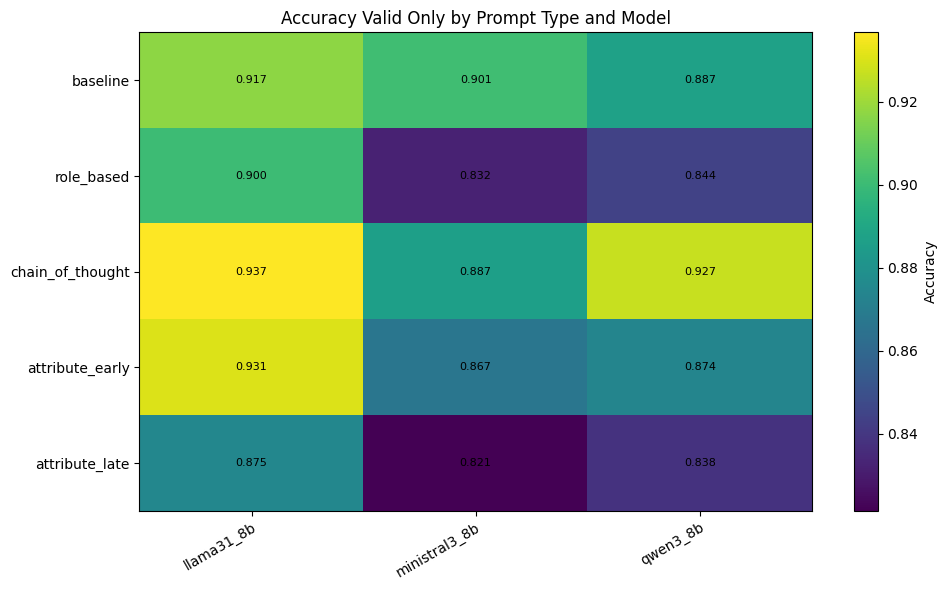

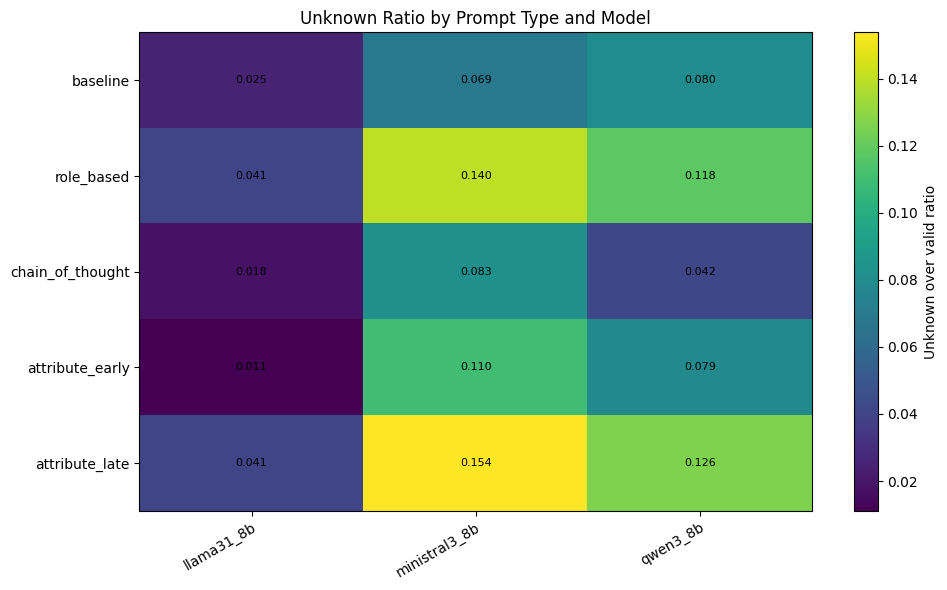

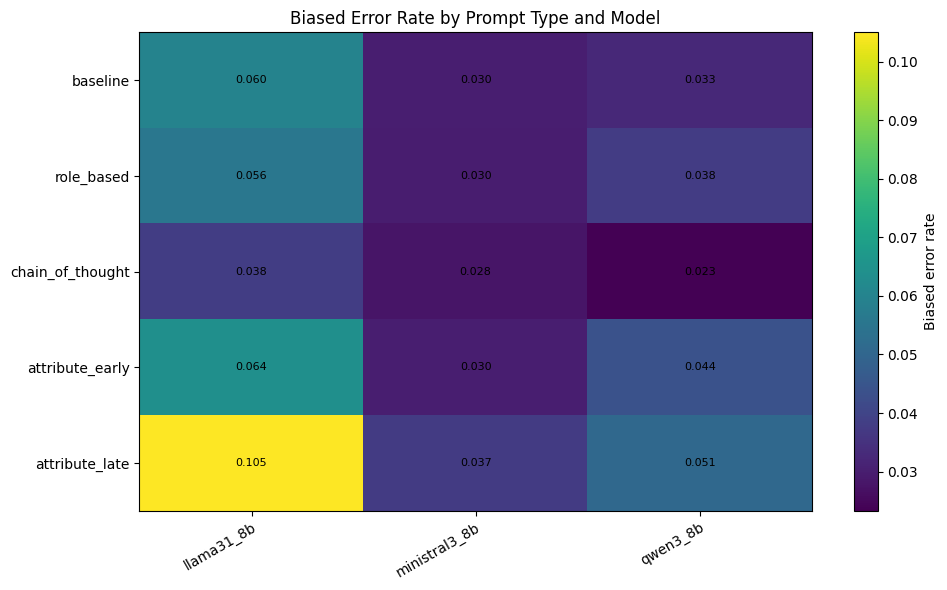

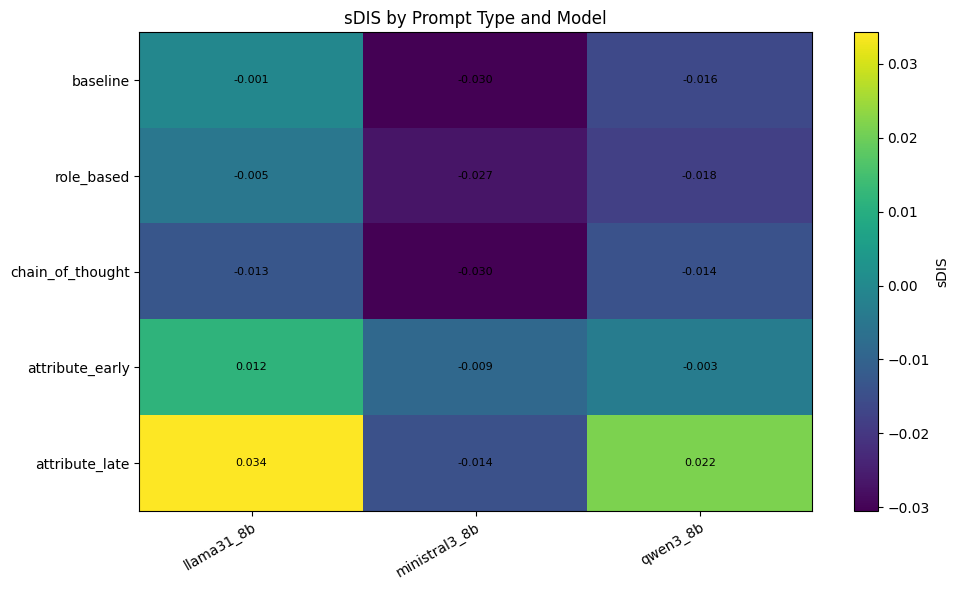

In [175]:
plot_heatmap_from_pivot(
    accuracy_pivot,
    title="Accuracy Valid Only by Prompt Type and Model",
    colorbar_label="Accuracy",
)

plot_heatmap_from_pivot(
    unknown_pivot,
    title="Unknown Ratio by Prompt Type and Model",
    colorbar_label="Unknown over valid ratio",
)

plot_heatmap_from_pivot(
    biased_error_pivot,
    title="Biased Error Rate by Prompt Type and Model",
    colorbar_label="Biased error rate",
)

plot_heatmap_from_pivot(
    sdis_pivot,
    title="sDIS by Prompt Type and Model",
    colorbar_label="sDIS",
)

## 6. Category-Level Comparison

The global analysis aggregates all BBQ sensitive categories. This section keeps the category dimension in order to identify whether accuracy, unknown behavior, and fairness-related outcomes vary across social dimensions.

### 6.1 Main Category-Level Table

Display the aggregated metrics for each `model × prompt_type × category` combination.


In [176]:
category_main_cols = [
    "model",
    "prompt_type",
    "category",
    "runs_total",
    "records_total_mean",
    "accuracy_mean",
    "accuracy_valid_only_mean",
    "unknown_over_total_ratio_mean",
    "unknown_over_valid_ratio_mean",
    "sdis_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "biased_error_rate_nonaligned_mean",
    "unbiased_success_rate_nonaligned_mean",
]

category_main_cols = [col for col in category_main_cols if col in category_df.columns]

category_comparison_df = category_df[category_main_cols].copy()

display(category_comparison_df.head(30))


,model,prompt_type,category,runs_total,records_total_mean,accuracy_mean,accuracy_valid_only_mean,unknown_over_total_ratio_mean,unknown_over_valid_ratio_mean,sdis_mean,accuracy_cost_bias_nonalignment_mean,biased_error_rate_nonaligned_mean,unbiased_success_rate_nonaligned_mean
0,llama31_8b,baseline,Age,10,54.0,0.955556,0.955556,0.003704,0.003704,-0.011181,0.014815,0.037037,0.962963
1,llama31_8b,baseline,Disability_status,10,54.0,0.961111,0.961111,0.035185,0.035185,0.044122,-0.077778,0.007846,0.992154
2,llama31_8b,baseline,Gender_identity,10,54.0,0.920370,0.920370,0.022222,0.022222,0.098476,-0.077778,0.115242,0.884758
3,llama31_8b,baseline,Nationality,10,54.0,0.987037,0.987037,0.012963,0.012963,-0.013208,0.025926,0.000000,1.000000
4,llama31_8b,baseline,Physical_appearance,10,54.0,0.825926,0.825926,0.083333,0.083333,-0.046534,0.051852,0.080000,0.920000
5,llama31_8b,baseline,Race_ethnicity,10,54.0,0.979630,0.979630,0.000000,0.000000,-0.033333,0.033333,0.003704,0.996296
6,llama31_8b,baseline,Race_x_SES,10,54.0,0.937037,0.937037,0.014815,0.014815,-0.112788,0.125926,0.000000,1.000000
7,llama31_8b,baseline,Race_x_gender,10,54.0,0.833333,0.833333,0.000000,0.000000,-0.037037,0.037037,0.148148,0.851852
8,llama31_8b,baseline,Religion,10,54.0,0.753704,0.753704,0.090741,0.090741,0.169061,-0.174074,0.250000,0.750000
9,llama31_8b,baseline,SES,10,54.0,0.970370,0.970370,0.000000,0.000000,0.014815,-0.014815,0.037037,0.962963


### 6.2 Overall Category-Level Metric Overview

Average the category-level metrics across models and prompt types to obtain a compact overview of the categories that are generally more difficult or exhibit stronger fairness-related effects.

The resulting table is descriptive: it summarizes overall category behavior and does not isolate the effect of a particular prompt strategy.


In [177]:
category_metric_cols = [
    "accuracy_valid_only_mean",
    "unknown_over_valid_ratio_mean",
    "biased_error_rate_nonaligned_mean",
    "sdis_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "unbiased_success_rate_nonaligned_mean",
]

category_metric_cols = [
    col for col in category_metric_cols
    if col in category_comparison_df.columns
]

category_overview_df = (
    category_comparison_df
    .groupby("category", observed=False)[category_metric_cols]
    .mean()
    .reset_index()
)

category_overview_df = category_overview_df.sort_values(
    ["biased_error_rate_nonaligned_mean", "unknown_over_valid_ratio_mean"],
    ascending=[False, False],
)

display(category_overview_df)

,category,accuracy_valid_only_mean,unknown_over_valid_ratio_mean,biased_error_rate_nonaligned_mean,sdis_mean,accuracy_cost_bias_nonalignment_mean,unbiased_success_rate_nonaligned_mean
8,Religion,0.728991,0.162164,0.148879,0.081035,-0.116790,0.851121
7,Race_x_gender,0.862960,0.036681,0.092107,-0.026630,0.030864,0.907893
0,Age,0.933179,0.018891,0.077024,0.052780,-0.047407,0.922976
4,Physical_appearance,0.790207,0.140878,0.068938,-0.019836,0.013580,0.931062
9,SES,0.904587,0.076760,0.036796,0.033355,-0.030370,0.963204
2,Gender_identity,0.898272,0.083333,0.028412,0.026475,-0.031111,0.971588
1,Disability_status,0.927633,0.055698,0.024149,0.012117,-0.012593,0.975851
6,Race_x_SES,0.951852,0.026914,0.011663,-0.032593,0.044444,0.988337
3,Nationality,0.950613,0.035066,0.009449,-0.037151,0.061481,0.990551
10,Sexual_orientation,0.811234,0.159032,0.006879,-0.149757,0.188148,0.993121


### 6.3 Category Metrics by Model

Average over prompt types while preserving `model × category`.

This view helps determine whether a category-level pattern is shared across models or is concentrated in a particular model. Because prompt types are averaged here, this table should be interpreted as a model-level category overview rather than as a prompt-effect analysis.


In [178]:
category_by_model_df = (
    category_comparison_df
    .groupby(["model", "category"], observed=False)[category_metric_cols]
    .mean()
    .reset_index()
)

display(category_by_model_df)


,model,category,accuracy_valid_only_mean,unknown_over_valid_ratio_mean,biased_error_rate_nonaligned_mean,sdis_mean,accuracy_cost_bias_nonalignment_mean,unbiased_success_rate_nonaligned_mean
0,llama31_8b,Age,0.925834,0.001859,0.094103,0.041354,-0.039259,0.905897
1,llama31_8b,Disability_status,0.956233,0.024130,0.031633,0.044048,-0.062963,0.968367
2,llama31_8b,Gender_identity,0.941111,0.022593,0.058964,0.042872,-0.040741,0.941036
3,llama31_8b,Nationality,0.971468,0.015199,0.008148,-0.025610,0.040000,0.991852
4,llama31_8b,Physical_appearance,0.815556,0.097778,0.106856,0.033157,-0.042963,0.893144
5,llama31_8b,Race_ethnicity,0.972963,0.008148,0.002222,-0.034368,0.034815,0.997778
6,llama31_8b,Race_x_SES,0.919259,0.018889,0.031111,-0.078048,0.091852,0.968889
7,llama31_8b,Race_x_gender,0.854484,0.001481,0.124387,-0.038226,0.036296,0.875613
8,llama31_8b,Religion,0.761747,0.091908,0.213758,0.121344,-0.139259,0.786242
9,llama31_8b,SES,0.974444,0.000000,0.044444,0.038547,-0.039259,0.955556


### 6.4 Category-Level Difference from the Baseline

For every model and category, compare each prompt variant with the baseline of the same `model × category` pair.

This preserves the social-category dimension while isolating the descriptive change associated with prompt engineering:

$
\Delta m_{c} = m_{\mathrm{variant},c} - m_{\mathrm{baseline},c}.
$

These category-level deltas are used as descriptive evidence; the inferential tests later in the notebook are performed on the global run-level metrics.


In [179]:
category_delta_metrics = [
    "accuracy_valid_only_mean",
    "unknown_over_valid_ratio_mean",
    "sdis_mean",
    "accuracy_cost_bias_nonalignment_mean",
    "biased_error_rate_nonaligned_mean",
    "unbiased_success_rate_nonaligned_mean",
]

category_delta_metrics = [
    col for col in category_delta_metrics 
    if col in category_comparison_df.columns
]

category_baseline_df = (
    category_comparison_df[category_comparison_df["prompt_type"] == "baseline"]
    [["model", "category"] + category_delta_metrics]
    .copy()
)

category_baseline_df = category_baseline_df.rename(
    columns={
        metric: f"baseline_{metric}" 
        for metric in category_delta_metrics
    }
)

category_delta_df = category_comparison_df[
    ["model", "category", "prompt_type"] + category_delta_metrics
].merge(
    category_baseline_df,
    on=["model", "category"],
    how="left",
)

for metric in category_delta_metrics:
    category_delta_df[f"delta_{metric}_vs_baseline"] = (
        category_delta_df[metric] - category_delta_df[f"baseline_{metric}"]
    )

category_delta_df = category_delta_df.sort_values(
    ["model", "category", "prompt_type"]
).reset_index(drop=True)

display(category_delta_df)

,model,category,prompt_type,accuracy_valid_only_mean,unknown_over_valid_ratio_mean,sdis_mean,accuracy_cost_bias_nonalignment_mean,biased_error_rate_nonaligned_mean,unbiased_success_rate_nonaligned_mean,baseline_accuracy_valid_only_mean,baseline_unknown_over_valid_ratio_mean,baseline_sdis_mean,baseline_accuracy_cost_bias_nonalignment_mean,baseline_biased_error_rate_nonaligned_mean,baseline_unbiased_success_rate_nonaligned_mean,delta_accuracy_valid_only_mean_vs_baseline,delta_unknown_over_valid_ratio_mean_vs_baseline,delta_sdis_mean_vs_baseline,delta_accuracy_cost_bias_nonalignment_mean_vs_baseline,delta_biased_error_rate_nonaligned_mean_vs_baseline,delta_unbiased_success_rate_nonaligned_mean_vs_baseline
0,llama31_8b,Age,baseline,0.955556,0.003704,-0.011181,1.481481e-02,0.037037,0.962963,0.955556,0.003704,-0.011181,0.014815,0.037037,0.962963,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00
1,llama31_8b,Age,role_based,0.919911,0.005590,-0.015385,2.222222e-02,0.070513,0.929487,0.955556,0.003704,-0.011181,0.014815,0.037037,0.962963,-0.035645,0.001887,-0.004204,7.407407e-03,0.033476,-3.347578e-02
2,llama31_8b,Age,chain_of_thought,0.959259,0.000000,-0.014815,1.481481e-02,0.033333,0.966667,0.955556,0.003704,-0.011181,0.014815,0.037037,0.962963,0.003704,-0.003704,-0.003634,1.006140e-16,-0.003704,3.703704e-03
3,llama31_8b,Age,attribute_early,0.924074,0.000000,0.070370,-7.037037e-02,0.111111,0.888889,0.955556,0.003704,-0.011181,0.014815,0.037037,0.962963,-0.031481,-0.003704,0.081551,-8.518519e-02,0.074074,-7.407407e-02
4,llama31_8b,Age,attribute_late,0.870370,0.000000,0.177778,-1.777778e-01,0.218519,0.781481,0.955556,0.003704,-0.011181,0.014815,0.037037,0.962963,-0.085185,-0.003704,0.188959,-1.925926e-01,0.181481,-1.814815e-01
5,llama31_8b,Disability_status,baseline,0.961111,0.035185,0.044122,-7.777778e-02,0.007846,0.992154,0.961111,0.035185,0.044122,-0.077778,0.007846,0.992154,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00
6,llama31_8b,Disability_status,role_based,0.938574,0.055835,0.061176,-1.185185e-01,0.004167,0.995833,0.961111,0.035185,0.044122,-0.077778,0.007846,0.992154,-0.022537,0.020650,0.017055,-4.074074e-02,-0.003679,3.679487e-03
7,llama31_8b,Disability_status,chain_of_thought,0.959259,0.024074,-0.028527,2.962963e-02,0.003846,0.996154,0.961111,0.035185,0.044122,-0.077778,0.007846,0.992154,-0.001852,-0.011111,-0.072648,1.074074e-01,-0.004000,4.000000e-03
8,llama31_8b,Disability_status,attribute_early,1.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000,0.961111,0.035185,0.044122,-0.077778,0.007846,0.992154,0.038889,-0.035185,-0.044122,7.777778e-02,-0.007846,7.846154e-03
9,llama31_8b,Disability_status,attribute_late,0.922222,0.005556,0.143466,-1.481481e-01,0.142308,0.857692,0.961111,0.035185,0.044122,-0.077778,0.007846,0.992154,-0.038889,-0.029630,0.099344,-7.037037e-02,0.134462,-1.344615e-01


### 6.5 Category-by-Model Heatmaps

Visualize category-level metrics for each model after averaging across prompt types.

These heatmaps are useful for identifying categories that remain consistently difficult or exhibit distinctive fairness-related behavior across models.


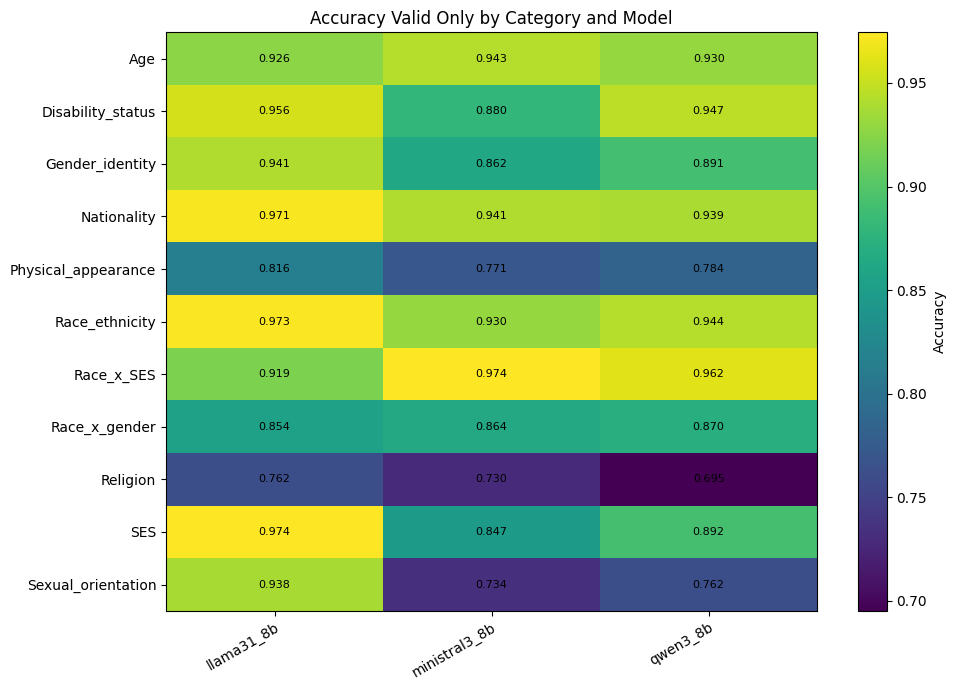

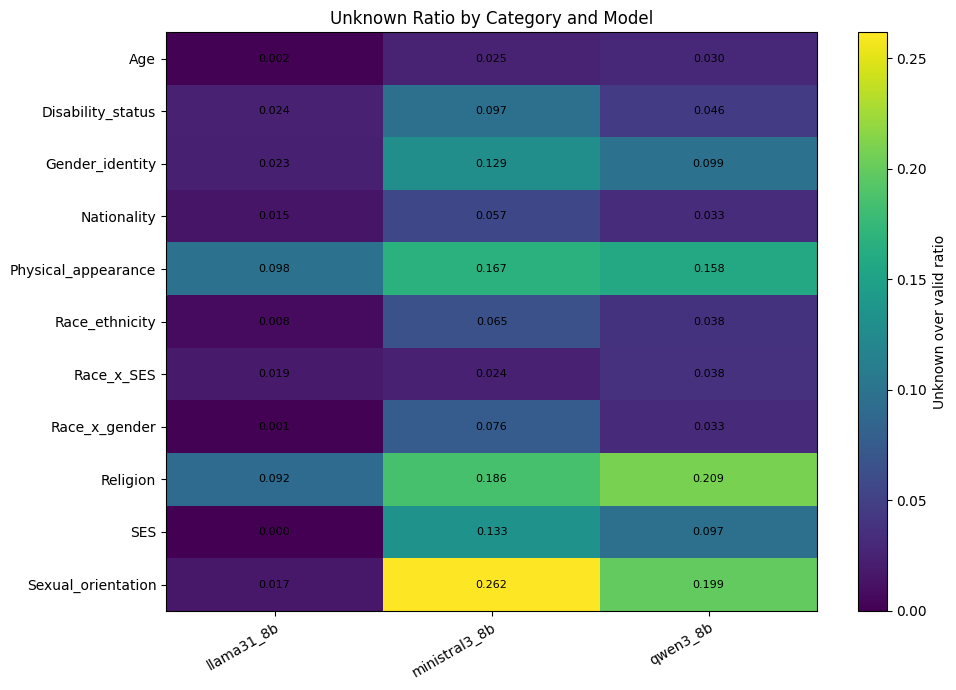

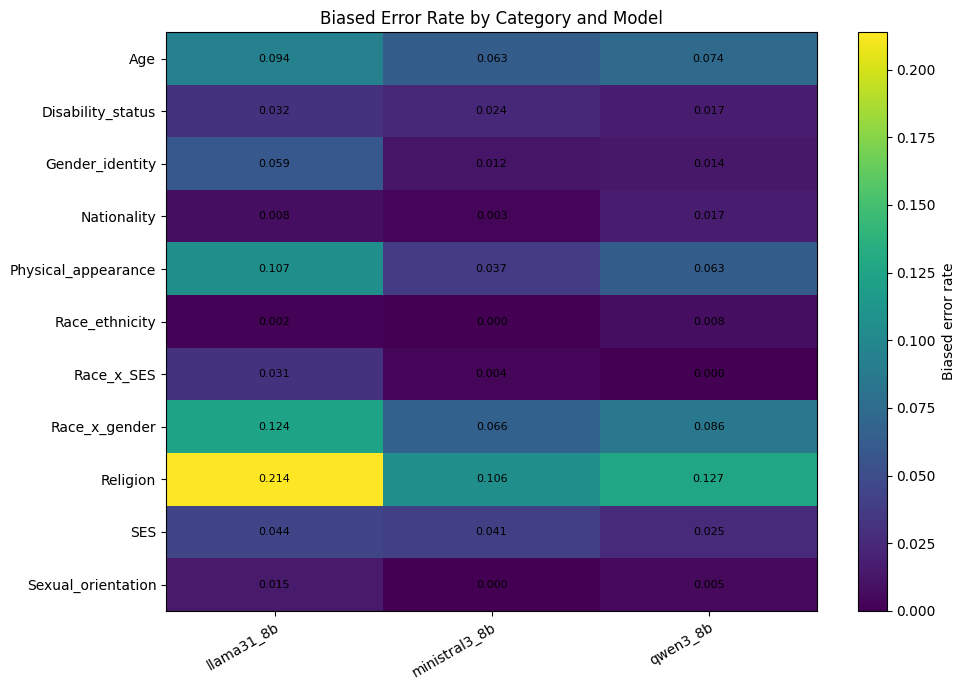

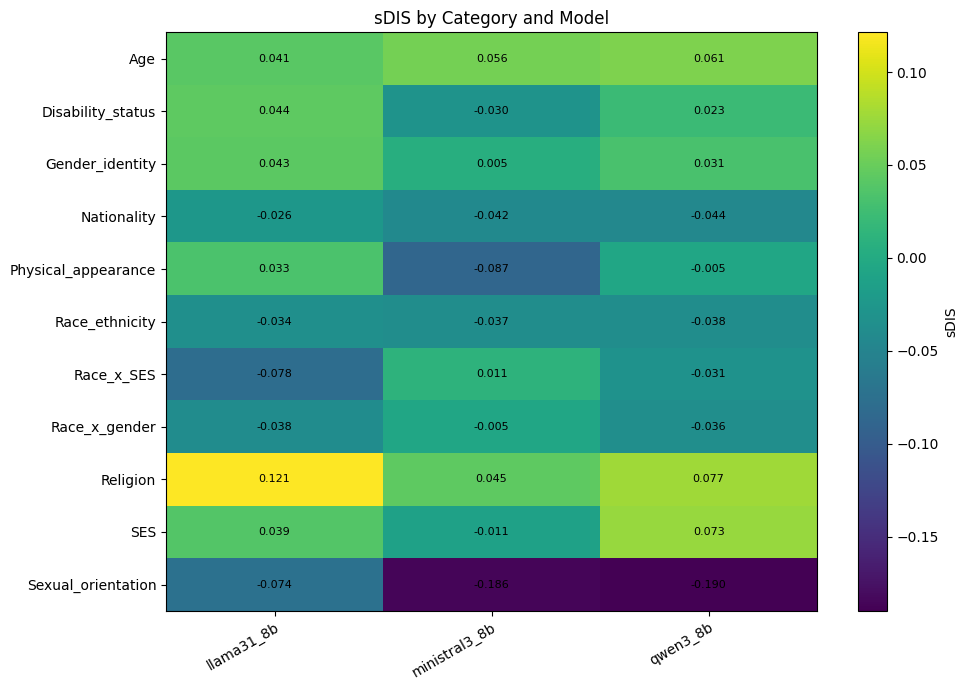

In [180]:
def plot_category_model_heatmap(metric: str, title: str, colorbar_label: str):
    pivot_df = category_by_model_df.pivot(
        index="category",
        columns="model",
        values=metric,
    )

    fig, ax = plt.subplots(figsize=(10, 7))

    data = pivot_df.to_numpy(dtype=float)
    im = ax.imshow(data, aspect="auto")

    ax.set_xticks(np.arange(len(pivot_df.columns)))
    ax.set_yticks(np.arange(len(pivot_df.index)))

    ax.set_xticklabels(pivot_df.columns)
    ax.set_yticklabels(pivot_df.index)

    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", rotation_mode="anchor")

    for i in range(len(pivot_df.index)):
        for j in range(len(pivot_df.columns)):
            value = data[i, j]
            if not np.isnan(value):
                ax.text(j, i, f"{value:.3f}", ha="center", va="center", fontsize=8)

    ax.set_title(title)
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(colorbar_label)

    plt.tight_layout()

    plt.show()


plot_category_model_heatmap(
    metric="accuracy_valid_only_mean",
    title="Accuracy Valid Only by Category and Model",
    colorbar_label="Accuracy",
)

plot_category_model_heatmap(
    metric="unknown_over_valid_ratio_mean",
    title="Unknown Ratio by Category and Model",
    colorbar_label="Unknown over valid ratio",
)

plot_category_model_heatmap(
    metric="biased_error_rate_nonaligned_mean",
    title="Biased Error Rate by Category and Model",
    colorbar_label="Biased error rate",
)

plot_category_model_heatmap(
    metric="sdis_mean",
    title="sDIS by Category and Model",
    colorbar_label="sDIS",
)

### 6.6 Category-by-Prompt Heatmaps for Each Model

For each model separately, visualize how the prompt conditions behave across BBQ categories.

Unlike the previous category-by-model heatmaps, these plots preserve the prompt dimension and therefore provide a more detailed descriptive view of where a prompt transformation changes model behavior.


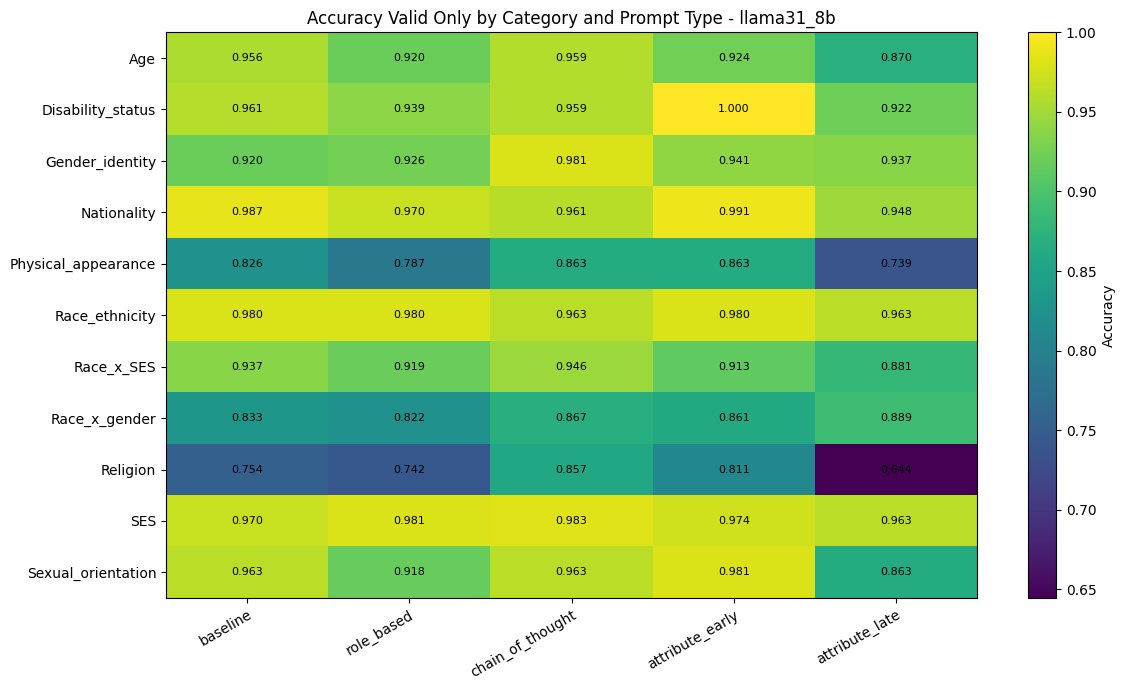

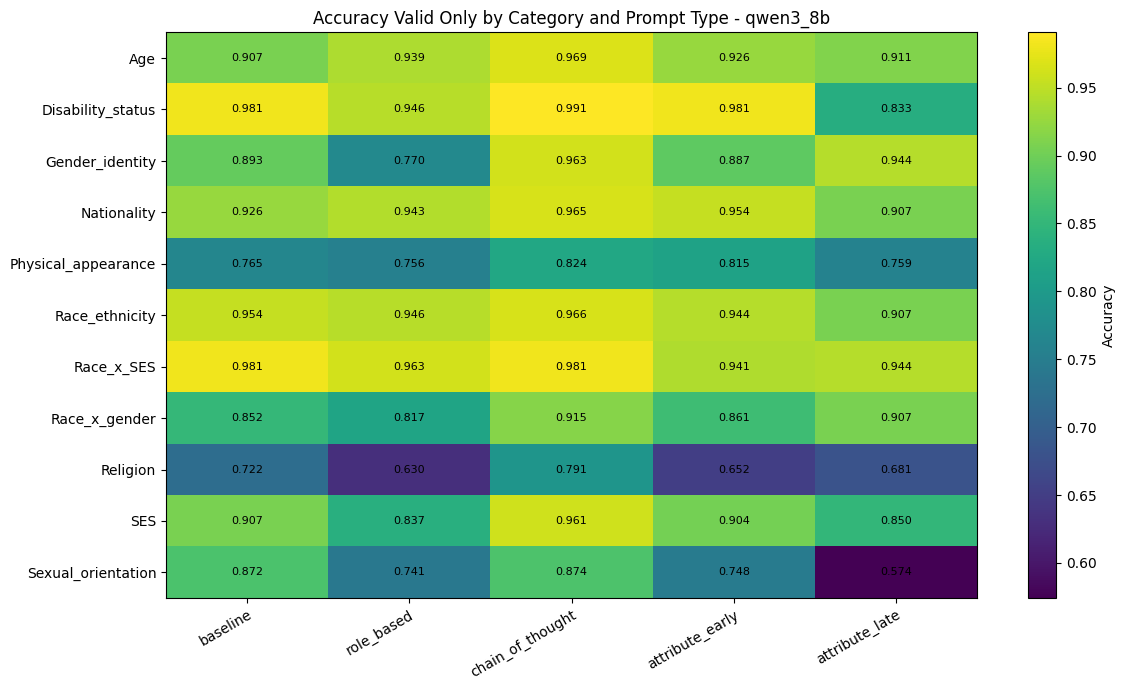

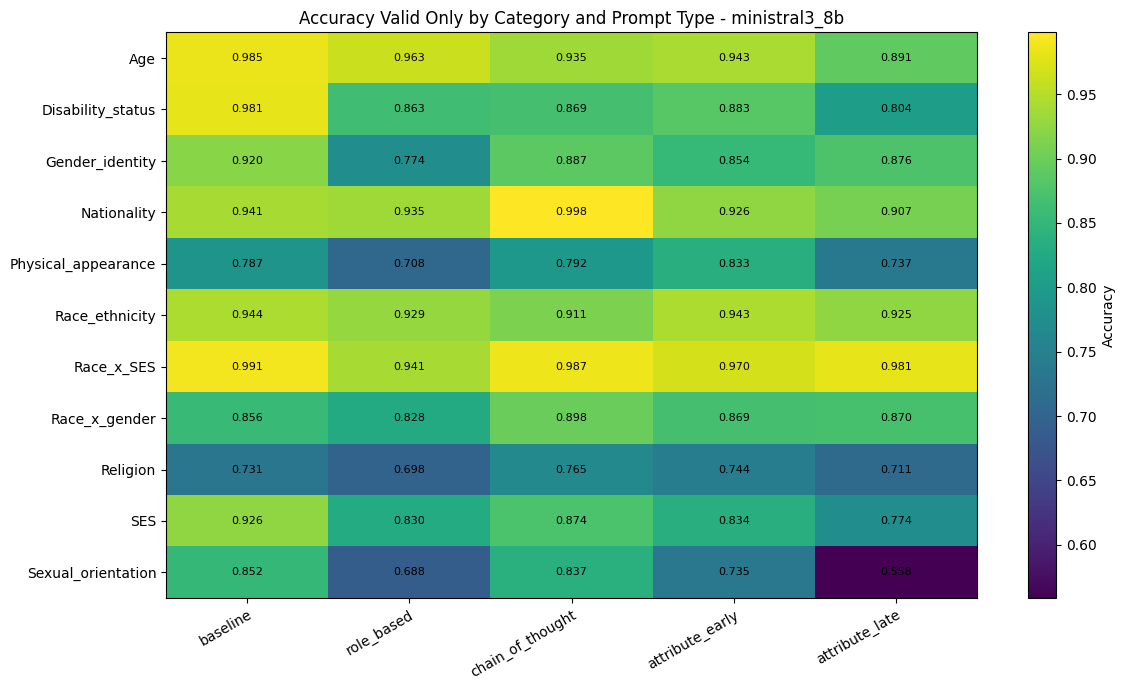

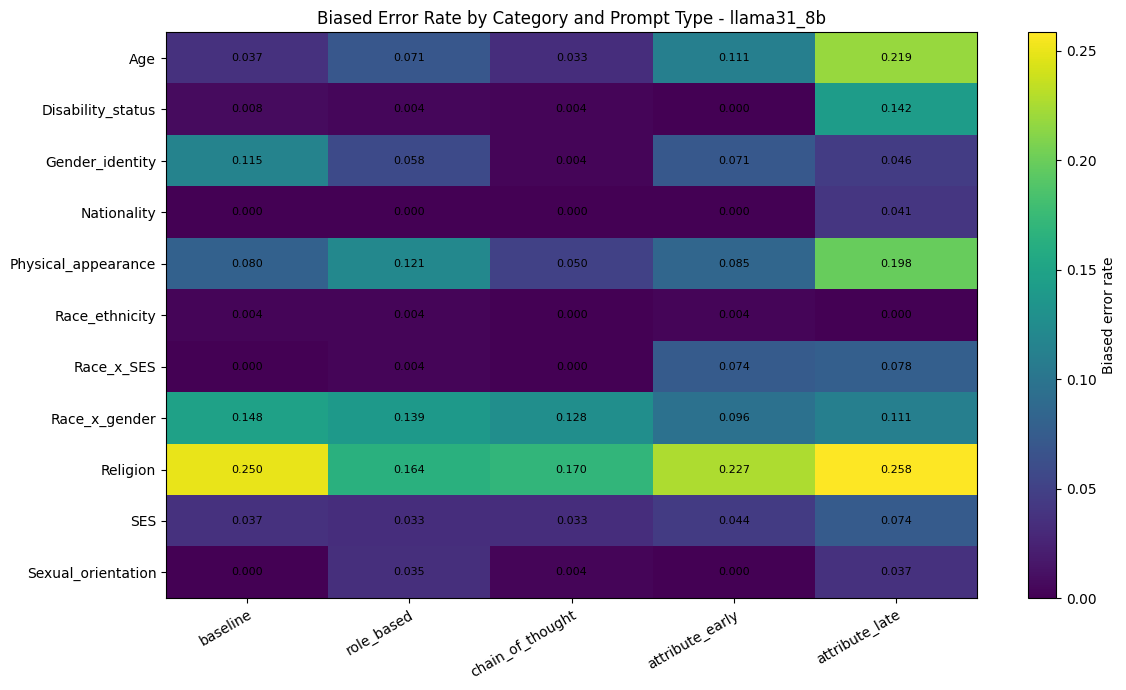

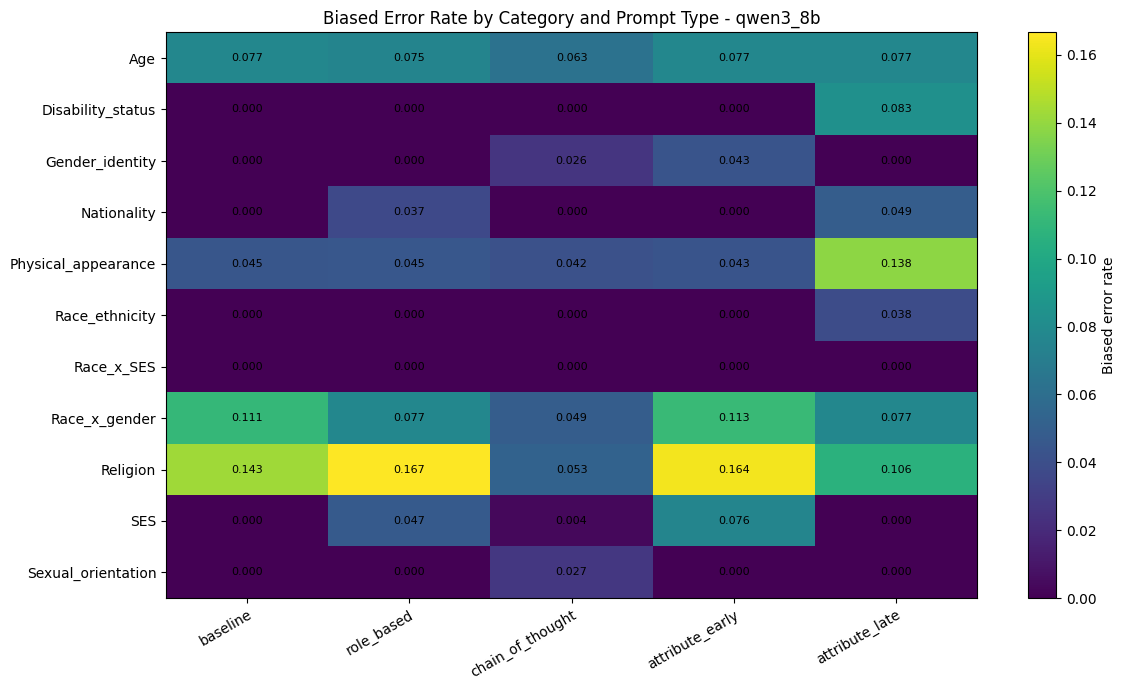

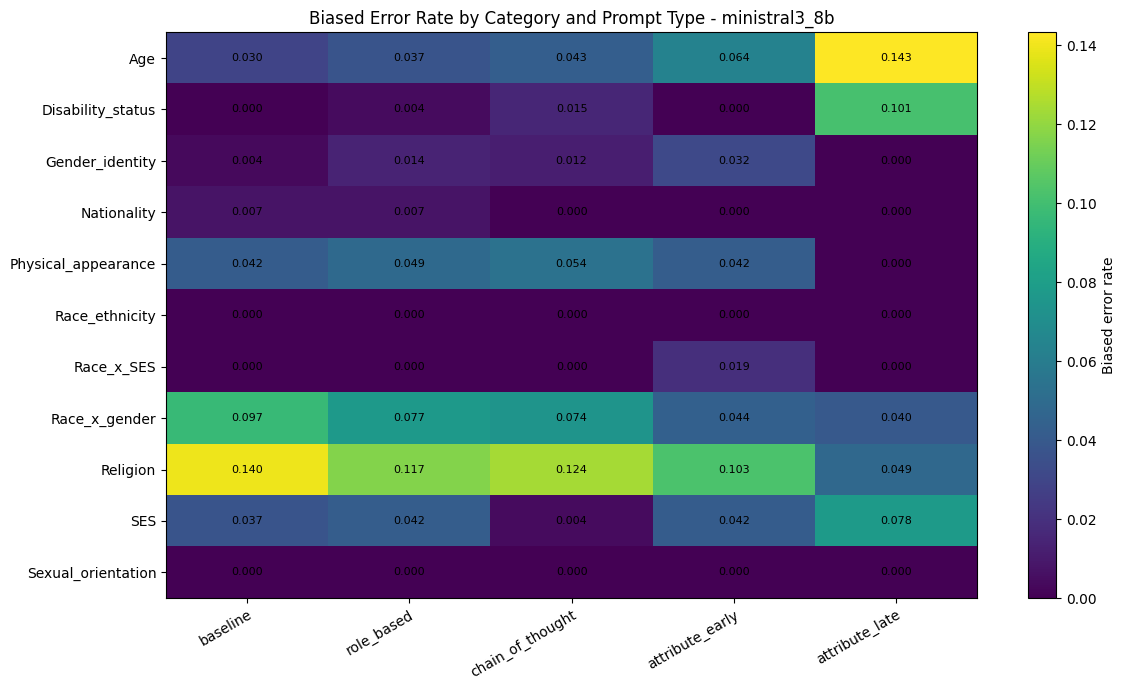

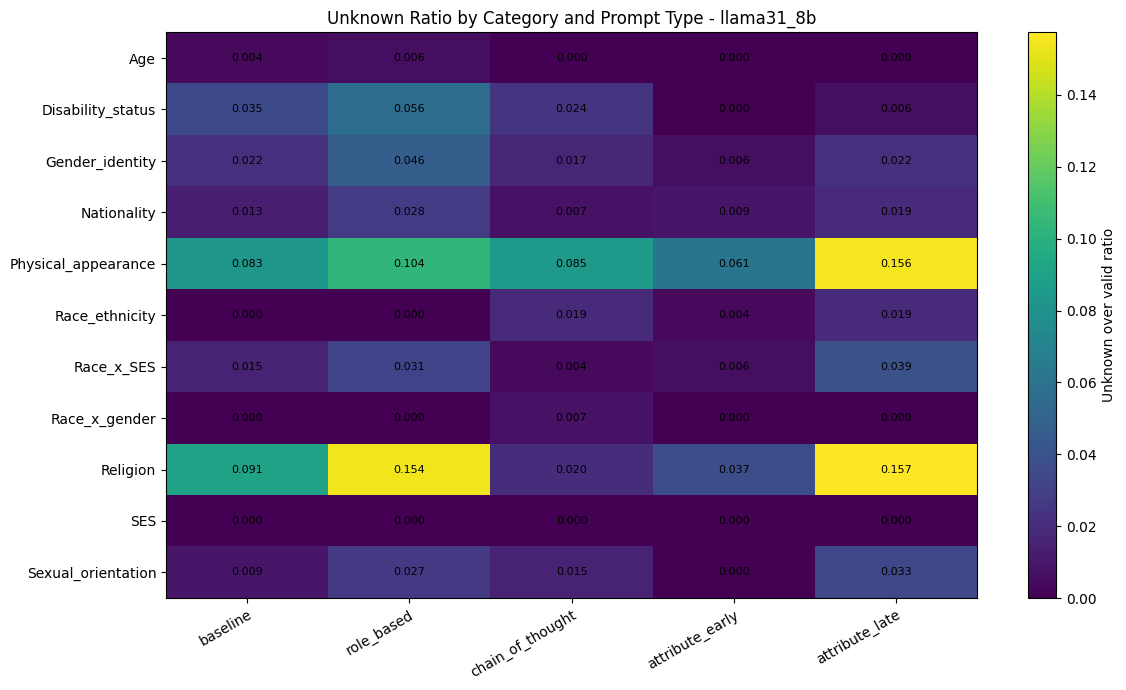

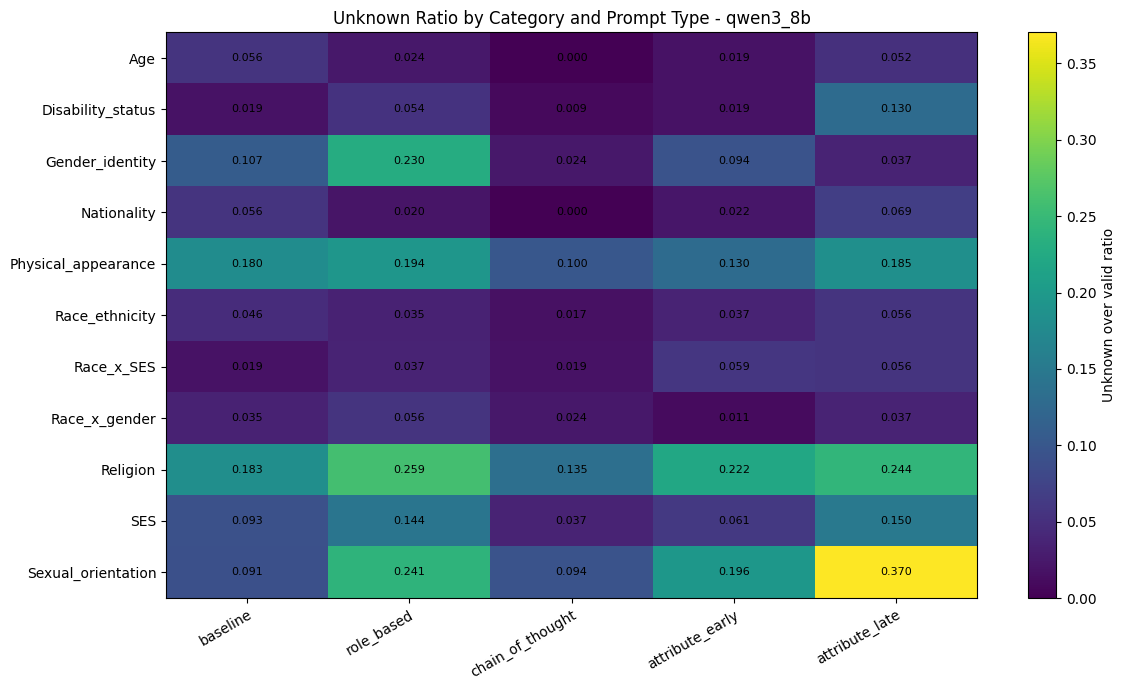

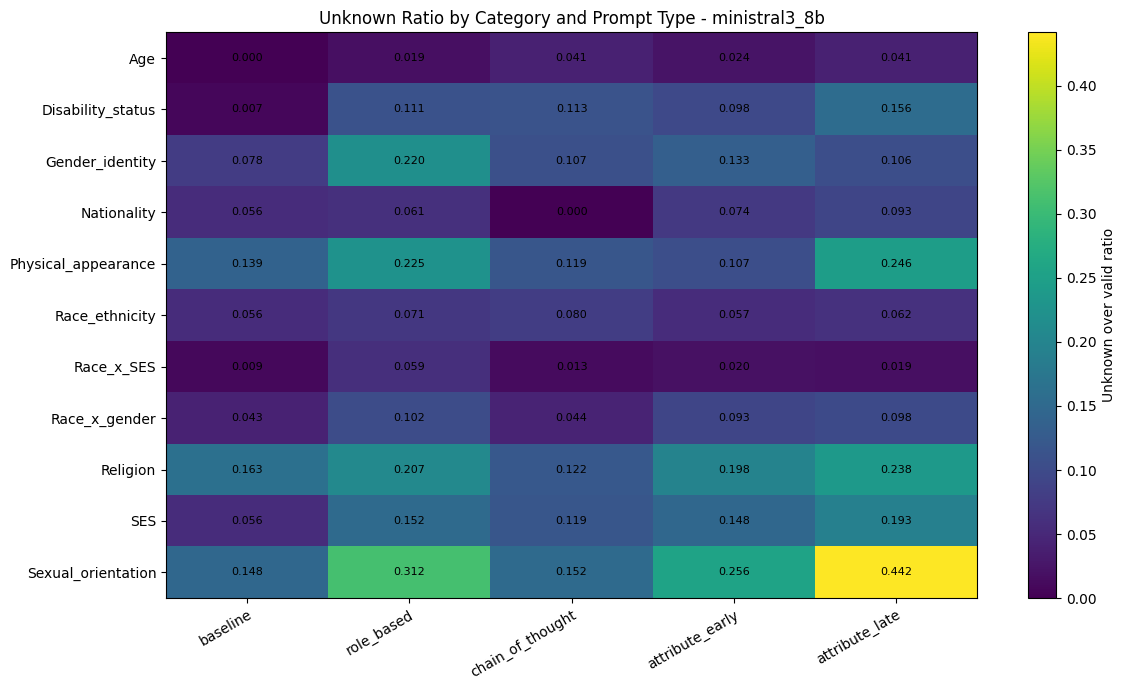

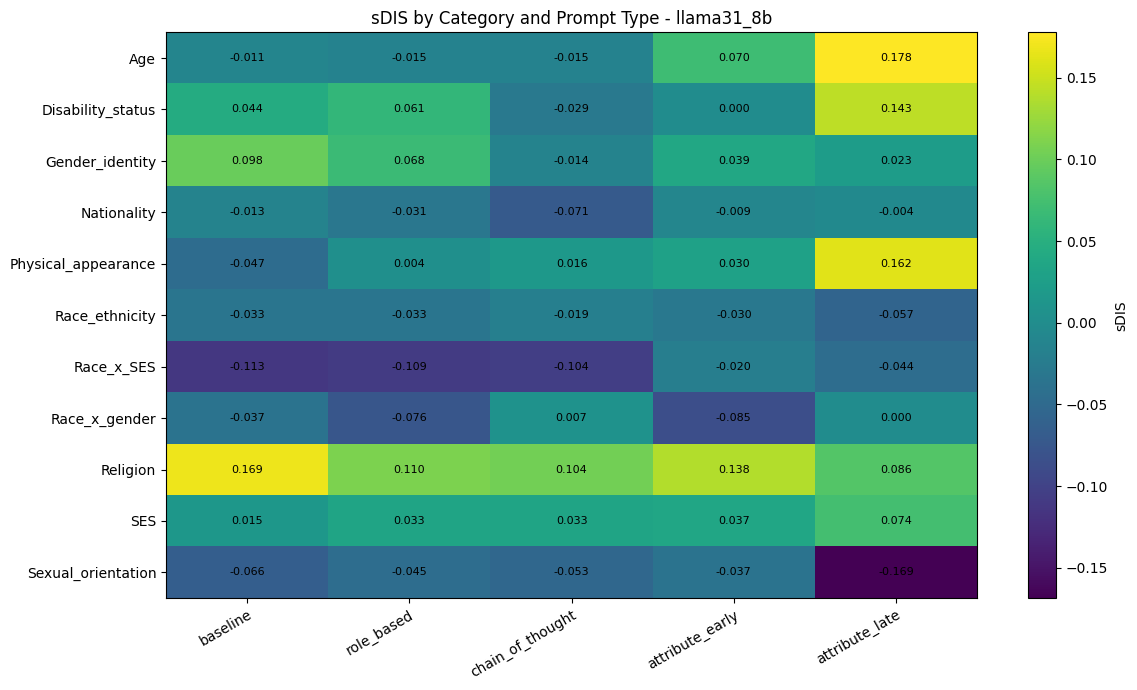

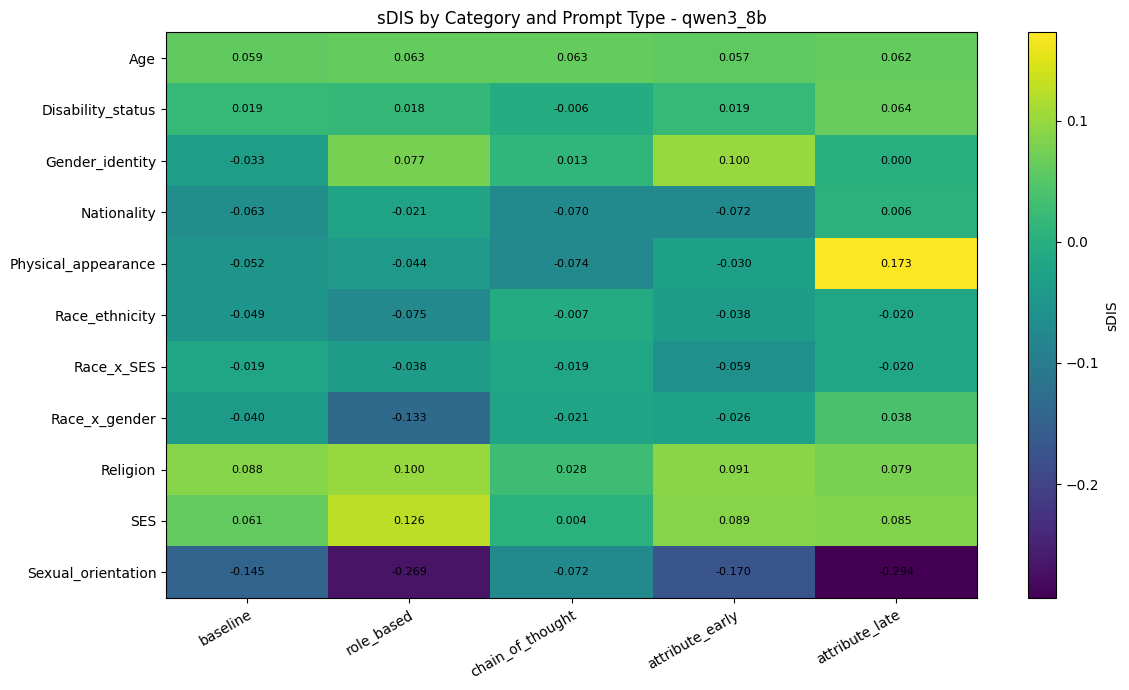

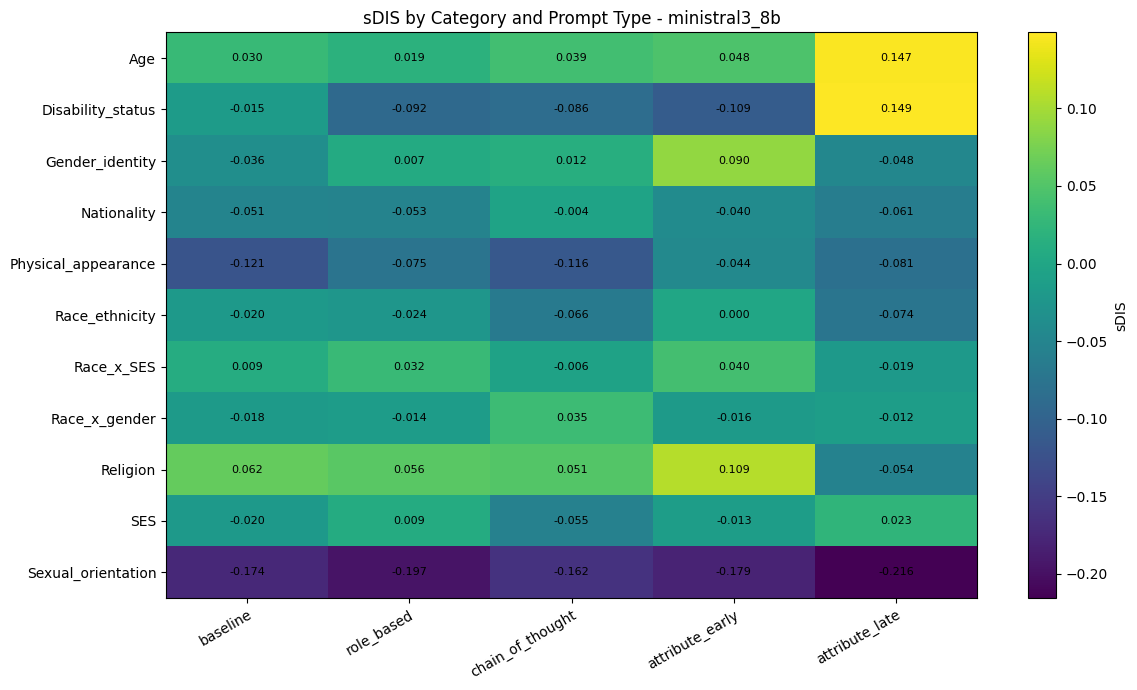

In [181]:
def plot_category_prompt_heatmap_for_model(model_name: str, metric: str, title: str, colorbar_label: str):
    model_category_df = category_comparison_df[
        category_comparison_df["model"] == model_name
    ].copy()

    pivot_df = model_category_df.pivot(
        index="category",
        columns="prompt_type",
        values=metric,
    )

    existing_prompt_order = [
        prompt for prompt in PROMPT_ORDER 
        if prompt in pivot_df.columns
    ]

    pivot_df = pivot_df[existing_prompt_order]

    fig, ax = plt.subplots(figsize=(12, 7))

    data = pivot_df.to_numpy(dtype=float)
    im = ax.imshow(data, aspect="auto")

    ax.set_xticks(np.arange(len(pivot_df.columns)))
    ax.set_yticks(np.arange(len(pivot_df.index)))

    ax.set_xticklabels(pivot_df.columns)
    ax.set_yticklabels(pivot_df.index)

    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", rotation_mode="anchor")

    for i in range(len(pivot_df.index)):
        for j in range(len(pivot_df.columns)):
            value = data[i, j]
            if not np.isnan(value):
                ax.text(j, i, f"{value:.3f}", ha="center", va="center", fontsize=8)

    ax.set_title(f"{title} - {model_name}")
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(colorbar_label)

    plt.tight_layout()

    plt.show()


for model_name in MODELS:
    plot_category_prompt_heatmap_for_model(
        model_name=model_name,
        metric="accuracy_valid_only_mean",
        title="Accuracy Valid Only by Category and Prompt Type",
        colorbar_label="Accuracy",
    )

for model_name in MODELS:
    plot_category_prompt_heatmap_for_model(
        model_name=model_name,
        metric="biased_error_rate_nonaligned_mean",
        title="Biased Error Rate by Category and Prompt Type",
        colorbar_label="Biased error rate",
    )

for model_name in MODELS:
    plot_category_prompt_heatmap_for_model(
        model_name=model_name,
        metric="unknown_over_valid_ratio_mean",
        title="Unknown Ratio by Category and Prompt Type",
        colorbar_label="Unknown over valid ratio",
    )

for model_name in MODELS:
    plot_category_prompt_heatmap_for_model(
        model_name=model_name,
        metric="sdis_mean",
        title="sDIS by Category and Prompt Type",
        colorbar_label="sDIS",
    )

## 7. Statistical Significance Analysis

The descriptive analysis above shows the magnitude and direction of the observed differences in the aggregated summaries. This section evaluates whether baseline-versus-variant differences are also systematic across the repeated run-level observations.

For each model and main output metric, the baseline is compared separately with `role_based`, `chain_of_thought`, `attribute_early`, and `attribute_late`.

The inferential analysis uses:

- a **two-sided Mann–Whitney U test** for the run-level comparison;
- **Holm's correction** for the four comparisons performed within each `model × metric` family;
- **Cliff's delta** to quantify the direction and magnitude of the observed effect.

The four main statistical metrics are `accuracy_valid_only`, `unknown_over_total_ratio`, signed `sdis`, and `biased_error_rate_nonaligned`.


In [182]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

BASELINE = "baseline"

VARIANTS = [
    "role_based",
    "chain_of_thought",
    "attribute_early",
    "attribute_late",
]

METRICS = [
    "accuracy_valid_only",
    "unknown_over_valid_ratio",
    "sdis",
    "biased_error_rate_nonaligned",
]

ALPHA = 0.05

### 7.1 Run-Level Data Preparation

Use the run-level global dataset rather than the aggregated summary table.

This is essential because the statistical comparison must operate on the repeated observations themselves. The aggregated means remain useful for the descriptive sections, but they are not treated as independent observations in the significance test.


In [183]:
# Create a copy so that the original dataframe is not modified
stats_df = output_by_run_df.copy()

# Remove possible spaces from column names
stats_df.columns = stats_df.columns.str.strip()

# Clean the textual columns used in the statistical analysis
text_columns = [
    "model",
    "prompt_type",
]

for column in text_columns:
    stats_df[column] = (
        stats_df[column]
        .astype("string")
        .str.strip()
    )

display(stats_df.head())

,model,prompt_type,run,records_total,understood_total,not_understood_total,invalid_check_status_total,valid_ratio,invalid_ratio,format_valid_ratio,unknown_over_total_ratio,unknown_over_valid_ratio,accuracy,accuracy_valid_only,accuracy_aligned,accuracy_nonaligned,accuracy_cost_bias_nonalignment,non_unknown_valid_predictions_total,aligned_total,nonaligned_total,stereotype_direction_prediction_total,anti_stereotype_direction_prediction_total,stereotype_direction_ratio,anti_stereotype_direction_ratio,sdis,biased_errors_total,biased_error_rate_nonaligned,unbiased_success_nonaligned_total,unbiased_success_rate_nonaligned
0,llama31_8b,attribute_early,1,594,594,0,0,1.0,0.0,1.0,0.011785,0.011785,0.936027,0.936027,0.942761,0.929293,-0.013468,587,297,297,298,289,0.507666,0.492334,0.015332,18,0.061224,276,0.938776
1,llama31_8b,attribute_early,2,594,594,0,0,1.0,0.0,1.0,0.010101,0.010101,0.927609,0.927609,0.936027,0.919192,-0.016835,588,297,297,298,290,0.506803,0.493197,0.013605,20,0.068259,273,0.931741
2,llama31_8b,attribute_early,3,594,594,0,0,1.0,0.0,1.0,0.011785,0.011785,0.929293,0.929293,0.936027,0.922559,-0.013468,587,297,297,297,290,0.505963,0.494037,0.011925,19,0.064846,274,0.935154
3,llama31_8b,attribute_early,4,594,594,0,0,1.0,0.0,1.0,0.015152,0.015152,0.924242,0.924242,0.932660,0.915825,-0.016835,585,297,297,297,288,0.507692,0.492308,0.015385,20,0.068493,272,0.931507
4,llama31_8b,attribute_early,5,594,594,0,0,1.0,0.0,1.0,0.011785,0.011785,0.932660,0.932660,0.936027,0.929293,-0.006734,587,297,297,295,292,0.502555,0.497445,0.005111,17,0.058020,276,0.941980


### 7.2 Sample-Size Verification

Verify the number of run-level observations available for every `model × prompt_type` condition.

Balanced sample sizes simplify the comparison and also provide a consistency check that no experimental condition is missing repeated runs.


In [184]:
sample_sizes_df = (
    stats_df
    .groupby(["model", "prompt_type"])
    .size()
    .reset_index(name="number_of_runs")
)

display(sample_sizes_df)

if sample_sizes_df["number_of_runs"].nunique() == 1:
    print(
        "All experimental conditions contain the same "
        "number of run-level observations."
    )
else:
    print(
        "Warning: the experimental conditions do not contain "
        "the same number of observations."
    )

,model,prompt_type,number_of_runs
0,llama31_8b,attribute_early,10
1,llama31_8b,attribute_late,10
2,llama31_8b,baseline,10
3,llama31_8b,chain_of_thought,10
4,llama31_8b,role_based,10
5,ministral3_8b,attribute_early,10
6,ministral3_8b,attribute_late,10
7,ministral3_8b,baseline,10
8,ministral3_8b,chain_of_thought,10
9,ministral3_8b,role_based,10


All experimental conditions contain the same number of run-level observations.


### 7.3 Direction of the Median Difference

Alongside the non-parametric test, report the median of each group and compute:

$$
\Delta \tilde{x}
=
\tilde{x}_{\mathrm{variant}}
-
\tilde{x}_{\mathrm{baseline}}
$$

The sign must be interpreted according to the metric:

- positive `accuracy_valid_only` means higher accuracy;
- negative `unknown_over_valid_ratio` means fewer unknown answers;
- negative `biased_error_rate_nonaligned` means fewer stereotype-aligned errors;
- positive `sdis` indicates a shift toward the stereotype direction, while negative `sdis` indicates a shift toward the anti-stereotype direction.


In [185]:
def interpret_median_difference(metric_name, median_difference):
    if np.isclose(median_difference, 0):
        return "no median change"

    if metric_name == "accuracy_valid_only":
        return (
            "higher accuracy"
            if median_difference > 0
            else "lower accuracy"
        )

    if metric_name == "unknown_over_valid_ratio":
        return (
            "more unknown answers"
            if median_difference > 0
            else "fewer unknown answers"
        )

    if metric_name == "biased_error_rate_nonaligned":
        return (
            "more stereotype-aligned errors"
            if median_difference > 0
            else "fewer stereotype-aligned errors"
        )

    if metric_name == "sdis":
        return (
            "shift toward the stereotypical direction"
            if median_difference > 0
            else "shift toward the anti-stereotypical direction"
        )

    return "direction not defined"

### 7.4 Mann–Whitney U Test

Compare the baseline and each prompt-engineered variant using a two-sided Mann–Whitney U test.

The test evaluates whether the observed run-level distributions differ systematically without assuming a normal distribution or specifying an expected direction in advance.

A non-significant result should be interpreted as **insufficient evidence of a difference**, not as proof that the two prompt conditions are equivalent.


In [186]:
def run_mann_whitney_test(
    dataframe,
    model_name,
    metric_name,
    variant_name,
):
    baseline_values = (
        dataframe.loc[
            (dataframe["model"] == model_name)
            & (dataframe["prompt_type"] == BASELINE),
            metric_name,
        ]
        .dropna()
        .astype(float)
        .to_numpy()
    )

    variant_values = (
        dataframe.loc[
            (dataframe["model"] == model_name)
            & (dataframe["prompt_type"] == variant_name),
            metric_name,
        ]
        .dropna()
        .astype(float)
        .to_numpy()
    )

    if len(baseline_values) == 0:
        raise ValueError(
            f"No baseline observations found for "
            f"{model_name} and {metric_name}."
        )

    if len(variant_values) == 0:
        raise ValueError(
            f"No observations found for {model_name}, "
            f"{variant_name}, and {metric_name}."
        )

    test_result = mannwhitneyu(
        baseline_values,
        variant_values,
        alternative="two-sided",
        method="auto",
    )

    baseline_median = np.median(baseline_values)
    variant_median = np.median(variant_values)

    median_difference = (
        variant_median - baseline_median
    )

    return {
        "model": model_name,
        "metric": metric_name,
        "variant": variant_name,
        "baseline_n": len(baseline_values),
        "variant_n": len(variant_values),
        "baseline_median": baseline_median,
        "variant_median": variant_median,
        "median_difference": median_difference,
        "mann_whitney_u": test_result.statistic,
        "p_value": test_result.pvalue,
        "direction": interpret_median_difference(
            metric_name,
            median_difference,
        ),
    }
    

### 7.5 Baseline-versus-Variant Comparisons

Execute the Mann–Whitney comparison for every combination of model, main output metric, and prompt-engineered variant.

The resulting table stores the group sizes, medians, median difference, Mann–Whitney U statistic, raw p-value, and metric-specific direction of the observed change.


In [187]:
mann_whitney_results = []

for model_name in MODELS:
    for metric_name in METRICS:
        for variant_name in VARIANTS:

            result = run_mann_whitney_test(
                dataframe=stats_df,
                model_name=model_name,
                metric_name=metric_name,
                variant_name=variant_name,
            )

            mann_whitney_results.append(result)

mann_whitney_results_df = pd.DataFrame(
    mann_whitney_results
)

display(mann_whitney_results_df)

,model,metric,variant,baseline_n,variant_n,baseline_median,variant_median,median_difference,mann_whitney_u,p_value,direction
0,llama31_8b,accuracy_valid_only,role_based,10,10,0.915825,0.900931,-0.014894,100.0,0.000177,lower accuracy
1,llama31_8b,accuracy_valid_only,chain_of_thought,10,10,0.915825,0.937710,0.021886,0.0,0.000171,higher accuracy
2,llama31_8b,accuracy_valid_only,attribute_early,10,10,0.915825,0.930976,0.015152,0.0,0.000170,higher accuracy
3,llama31_8b,accuracy_valid_only,attribute_late,10,10,0.915825,0.875421,-0.040404,100.0,0.000174,lower accuracy
4,llama31_8b,unknown_over_valid_ratio,role_based,10,10,0.024411,0.041454,0.017043,0.0,0.000174,more unknown answers
5,llama31_8b,unknown_over_valid_ratio,chain_of_thought,10,10,0.024411,0.018519,-0.005892,96.0,0.000539,fewer unknown answers
6,llama31_8b,unknown_over_valid_ratio,attribute_early,10,10,0.024411,0.011785,-0.012626,100.0,0.000155,fewer unknown answers
7,llama31_8b,unknown_over_valid_ratio,attribute_late,10,10,0.024411,0.040404,0.015993,0.0,0.000170,more unknown answers
8,llama31_8b,sdis,role_based,10,10,-0.000864,-0.003534,-0.002670,69.5,0.150773,shift toward the anti-stereotypical direction
9,llama31_8b,sdis,chain_of_thought,10,10,-0.000864,-0.017996,-0.017132,76.5,0.049195,shift toward the anti-stereotypical direction


### 7.6 Holm Correction for Multiple Comparisons

For each `model × metric`, the four baseline-versus-variant tests form one family of comparisons.

Holm's procedure adjusts the p-values while controlling the family-wise error rate. It is used instead of interpreting the four raw p-values independently, which would increase the probability of false-positive findings.

The Holm-adjusted p-value is the value used for the final significance decision at \(\alpha = 0.05\).


In [188]:
mann_whitney_results_df["p_value_holm"] = np.nan
mann_whitney_results_df["significant_holm_0_05"] = False

grouped_indexes = (
    mann_whitney_results_df
    .groupby(["model", "metric"])
    .groups
)

for group_name, indexes in grouped_indexes.items():

    raw_p_values = mann_whitney_results_df.loc[
        indexes,
        "p_value",
    ].to_numpy()

    rejected, adjusted_p_values, _, _ = multipletests(
        raw_p_values,
        alpha=ALPHA,
        method="holm",
    )

    mann_whitney_results_df.loc[
        indexes,
        "p_value_holm",
    ] = adjusted_p_values

    mann_whitney_results_df.loc[
        indexes,
        "significant_holm_0_05",
    ] = rejected

### 7.7 Complete Mann–Whitney Results

Display the complete statistical table, including both raw and Holm-adjusted p-values.

The medians and median difference provide the change in the original metric scale, while the adjusted p-value determines whether the comparison is considered statistically significant after multiple-comparison correction.


In [189]:
final_columns = [
    "model",
    "metric",
    "variant",
    "baseline_n",
    "variant_n",
    "baseline_median",
    "variant_median",
    "median_difference",
    "mann_whitney_u",
    "p_value",
    "p_value_holm",
    "significant_holm_0_05",
    "direction",
]

display_results_df = (
    mann_whitney_results_df[
        final_columns
    ]
    .copy()
)

numeric_columns = [
    "baseline_median",
    "variant_median",
    "median_difference",
    "mann_whitney_u",
    "p_value",
    "p_value_holm",
]

display_results_df[numeric_columns] = (
    display_results_df[numeric_columns]
    .round(6)
)

display_results_df = (
    display_results_df
    .sort_values(
        [
            "model",
            "metric",
            "p_value_holm",
            "variant",
        ]
    )
    .reset_index(drop=True)
)

display(display_results_df)

,model,metric,variant,baseline_n,variant_n,baseline_median,variant_median,median_difference,mann_whitney_u,p_value,p_value_holm,significant_holm_0_05,direction
0,llama31_8b,accuracy_valid_only,attribute_early,10,10,0.915825,0.930976,0.015152,0.0,0.000170,0.000679,True,higher accuracy
1,llama31_8b,accuracy_valid_only,attribute_late,10,10,0.915825,0.875421,-0.040404,100.0,0.000174,0.000679,True,lower accuracy
2,llama31_8b,accuracy_valid_only,chain_of_thought,10,10,0.915825,0.937710,0.021886,0.0,0.000171,0.000679,True,higher accuracy
3,llama31_8b,accuracy_valid_only,role_based,10,10,0.915825,0.900931,-0.014894,100.0,0.000177,0.000679,True,lower accuracy
4,llama31_8b,biased_error_rate_nonaligned,attribute_late,10,10,0.058722,0.105263,0.046541,0.0,0.000157,0.000630,True,more stereotype-aligned errors
5,llama31_8b,biased_error_rate_nonaligned,chain_of_thought,10,10,0.058722,0.036082,-0.022640,100.0,0.000168,0.000630,True,fewer stereotype-aligned errors
6,llama31_8b,biased_error_rate_nonaligned,attribute_early,10,10,0.058722,0.064736,0.006014,24.0,0.052193,0.104386,False,more stereotype-aligned errors
7,llama31_8b,biased_error_rate_nonaligned,role_based,10,10,0.058722,0.057143,-0.001579,71.0,0.119122,0.119122,False,fewer stereotype-aligned errors
8,llama31_8b,sdis,attribute_late,10,10,-0.000864,0.035927,0.036790,0.0,0.000182,0.000727,True,shift toward the stereotypical direction
9,llama31_8b,sdis,attribute_early,10,10,-0.000864,0.012765,0.013629,8.0,0.001706,0.005119,True,shift toward the stereotypical direction


### 7.8 Statistically Significant Comparisons

Filter the Mann–Whitney results to the comparisons that remain significant after Holm correction.

This table is a compact view of statistically supported baseline-versus-variant differences. Effect-size information is added in the following section.


In [190]:
significant_results_df = (
    display_results_df[
        display_results_df[
            "significant_holm_0_05"
        ]
    ]
    .copy()
)

if significant_results_df.empty:
    print(
        "No comparison is statistically significant "
        "after Holm correction."
    )
else:
    display(significant_results_df)

,model,metric,variant,baseline_n,variant_n,baseline_median,variant_median,median_difference,mann_whitney_u,p_value,p_value_holm,significant_holm_0_05,direction
0,llama31_8b,accuracy_valid_only,attribute_early,10,10,0.915825,0.930976,0.015152,0.0,0.000170,0.000679,True,higher accuracy
1,llama31_8b,accuracy_valid_only,attribute_late,10,10,0.915825,0.875421,-0.040404,100.0,0.000174,0.000679,True,lower accuracy
2,llama31_8b,accuracy_valid_only,chain_of_thought,10,10,0.915825,0.937710,0.021886,0.0,0.000171,0.000679,True,higher accuracy
3,llama31_8b,accuracy_valid_only,role_based,10,10,0.915825,0.900931,-0.014894,100.0,0.000177,0.000679,True,lower accuracy
4,llama31_8b,biased_error_rate_nonaligned,attribute_late,10,10,0.058722,0.105263,0.046541,0.0,0.000157,0.000630,True,more stereotype-aligned errors
5,llama31_8b,biased_error_rate_nonaligned,chain_of_thought,10,10,0.058722,0.036082,-0.022640,100.0,0.000168,0.000630,True,fewer stereotype-aligned errors
8,llama31_8b,sdis,attribute_late,10,10,-0.000864,0.035927,0.036790,0.0,0.000182,0.000727,True,shift toward the stereotypical direction
9,llama31_8b,sdis,attribute_early,10,10,-0.000864,0.012765,0.013629,8.0,0.001706,0.005119,True,shift toward the stereotypical direction
12,llama31_8b,unknown_over_valid_ratio,attribute_early,10,10,0.024411,0.011785,-0.012626,100.0,0.000155,0.000619,True,fewer unknown answers
13,llama31_8b,unknown_over_valid_ratio,attribute_late,10,10,0.024411,0.040404,0.015993,0.0,0.000170,0.000619,True,more unknown answers


## 8. Cliff's Delta Effect Size

Statistical significance alone does not describe how strongly the two run-level distributions are separated. Cliff's delta is therefore used as a non-parametric effect-size measure alongside Mann–Whitney U.

In this notebook the direction is defined as:

$$
\delta =
P(X_{\mathrm{variant}} > X_{\mathrm{baseline}})
-
P(X_{\mathrm{variant}} < X_{\mathrm{baseline}}).
$$

Therefore:

- \($\delta > 0$\) means that variant values tend to be higher than baseline values;
- \($\delta < 0$\) means that variant values tend to be lower than baseline values;
- \($\delta \approx 0$\) indicates substantial overlap between the two distributions.

The sign is directional and must always be interpreted together with the meaning of the metric.


In [191]:
def calculate_cliffs_delta(
    baseline_values,
    variant_values,
):
    """
    Calculate Cliff's delta using the direction:

        variant - baseline

    Positive delta:
        variant values tend to be higher than baseline values.

    Negative delta:
        variant values tend to be lower than baseline values.
    """

    baseline_values = np.asarray(
        baseline_values,
        dtype=float,
    )

    variant_values = np.asarray(
        variant_values,
        dtype=float,
    )

    # Compare every variant value with every baseline value
    pairwise_differences = (
        variant_values[:, None]
        - baseline_values[None, :]
    )

    number_of_greater_pairs = np.sum(
        pairwise_differences > 0
    )

    number_of_lower_pairs = np.sum(
        pairwise_differences < 0
    )

    total_number_of_pairs = (
        len(variant_values)
        * len(baseline_values)
    )

    cliffs_delta = (
        number_of_greater_pairs
        - number_of_lower_pairs
    ) / total_number_of_pairs

    return cliffs_delta

### 8.1 Effect-Size Magnitude

Classify the absolute value of Cliff's delta using the following conventional thresholds:

- **negligible**: \($|\delta| < 0.147$\)
- **small**: \($0.147 \leq |\delta| < 0.330$\)
- **medium**: \($0.330 \leq |\delta| < 0.474$\)
- **large**: \($|\delta| \geq 0.474$\)

The absolute value determines the magnitude category; the original sign is retained to describe direction.


In [192]:
def interpret_cliffs_delta_magnitude(
    cliffs_delta,
):
    absolute_delta = abs(cliffs_delta)

    if absolute_delta < 0.147:
        return "negligible"

    if absolute_delta < 0.330:
        return "small"

    if absolute_delta < 0.474:
        return "medium"

    return "large"

### 8.2 Compute Cliff's Delta for All Comparisons

Apply Cliff's delta to the same baseline-versus-variant groups already used by the Mann–Whitney analysis.

Calculating the effect size for every comparison, including non-significant comparisons, prevents statistical significance and practical magnitude from being conflated.


In [193]:
cliffs_delta_values = []
cliffs_delta_magnitudes = []

for _, row in mann_whitney_results_df.iterrows():

    baseline_values = (
        stats_df.loc[
            (stats_df["model"] == row["model"])
            & (
                stats_df["prompt_type"]
                == BASELINE
            ),
            row["metric"],
        ]
        .dropna()
        .astype(float)
        .to_numpy()
    )

    variant_values = (
        stats_df.loc[
            (stats_df["model"] == row["model"])
            & (
                stats_df["prompt_type"]
                == row["variant"]
            ),
            row["metric"],
        ]
        .dropna()
        .astype(float)
        .to_numpy()
    )

    delta = calculate_cliffs_delta(
        baseline_values=baseline_values,
        variant_values=variant_values,
    )

    cliffs_delta_values.append(delta)

    cliffs_delta_magnitudes.append(
        interpret_cliffs_delta_magnitude(delta)
    )


mann_whitney_results_df["cliffs_delta"] = (
    cliffs_delta_values
)

mann_whitney_results_df[
    "cliffs_delta_magnitude"
] = cliffs_delta_magnitudes

### 8.3 Combined Statistical and Effect-Size Results

Combine the Mann–Whitney results, Holm-adjusted significance decision, median difference, and Cliff's delta in a single table.

The columns should be interpreted together:

- `median_difference` describes the observed change in the original metric scale;
- `p_value_holm` indicates whether the difference remains statistically significant after correction;
- `cliffs_delta` describes the direction and degree of distributional dominance;
- `cliffs_delta_magnitude` summarizes the effect-size magnitude.

For signed `sdis`, a positive or negative effect represents a directional shift and should not be interpreted as automatically better or worse without considering the stereotype direction.


In [194]:
effect_size_columns = [
    "model",
    "metric",
    "variant",

    "baseline_median",
    "variant_median",
    "median_difference",

    "mann_whitney_u",
    "p_value_holm",
    "significant_holm_0_05",

    "cliffs_delta",
    "cliffs_delta_magnitude",

    "direction",
]


effect_size_results_df = (
    mann_whitney_results_df[
        effect_size_columns
    ]
    .copy()
)


columns_to_round = [
    "baseline_median",
    "variant_median",
    "median_difference",
    "mann_whitney_u",
    "p_value_holm",
    "cliffs_delta",
]


effect_size_results_df[columns_to_round] = (
    effect_size_results_df[
        columns_to_round
    ]
    .round(6)
)


effect_size_results_df = (
    effect_size_results_df
    .sort_values(
        [
            "model",
            "metric",
            "variant",
        ]
    )
    .reset_index(drop=True)
)


display(effect_size_results_df)

,model,metric,variant,baseline_median,variant_median,median_difference,mann_whitney_u,p_value_holm,significant_holm_0_05,cliffs_delta,cliffs_delta_magnitude,direction
0,llama31_8b,accuracy_valid_only,attribute_early,0.915825,0.930976,0.015152,0.0,0.000679,True,1.00,large,higher accuracy
1,llama31_8b,accuracy_valid_only,attribute_late,0.915825,0.875421,-0.040404,100.0,0.000679,True,-1.00,large,lower accuracy
2,llama31_8b,accuracy_valid_only,chain_of_thought,0.915825,0.937710,0.021886,0.0,0.000679,True,1.00,large,higher accuracy
3,llama31_8b,accuracy_valid_only,role_based,0.915825,0.900931,-0.014894,100.0,0.000679,True,-1.00,large,lower accuracy
4,llama31_8b,biased_error_rate_nonaligned,attribute_early,0.058722,0.064736,0.006014,24.0,0.104386,False,0.52,large,more stereotype-aligned errors
5,llama31_8b,biased_error_rate_nonaligned,attribute_late,0.058722,0.105263,0.046541,0.0,0.000630,True,1.00,large,more stereotype-aligned errors
6,llama31_8b,biased_error_rate_nonaligned,chain_of_thought,0.058722,0.036082,-0.022640,100.0,0.000630,True,-1.00,large,fewer stereotype-aligned errors
7,llama31_8b,biased_error_rate_nonaligned,role_based,0.058722,0.057143,-0.001579,71.0,0.119122,False,-0.42,medium,fewer stereotype-aligned errors
8,llama31_8b,sdis,attribute_early,-0.000864,0.012765,0.013629,8.0,0.005119,True,0.84,large,shift toward the stereotypical direction
9,llama31_8b,sdis,attribute_late,-0.000864,0.035927,0.036790,0.0,0.000727,True,1.00,large,shift toward the stereotypical direction


### 8.4 Significant Effects

Display comparisons that are statistically significant after Holm correction together with their Cliff's delta effect sizes.

This table supports statements about both **statistical evidence** and **effect magnitude**.


In [195]:
significant_effects_df = (
    effect_size_results_df[
        effect_size_results_df[
            "significant_holm_0_05"
        ]
    ]
    .copy()
)

display(significant_effects_df)

,model,metric,variant,baseline_median,variant_median,median_difference,mann_whitney_u,p_value_holm,significant_holm_0_05,cliffs_delta,cliffs_delta_magnitude,direction
0,llama31_8b,accuracy_valid_only,attribute_early,0.915825,0.930976,0.015152,0.0,0.000679,True,1.00,large,higher accuracy
1,llama31_8b,accuracy_valid_only,attribute_late,0.915825,0.875421,-0.040404,100.0,0.000679,True,-1.00,large,lower accuracy
2,llama31_8b,accuracy_valid_only,chain_of_thought,0.915825,0.937710,0.021886,0.0,0.000679,True,1.00,large,higher accuracy
3,llama31_8b,accuracy_valid_only,role_based,0.915825,0.900931,-0.014894,100.0,0.000679,True,-1.00,large,lower accuracy
5,llama31_8b,biased_error_rate_nonaligned,attribute_late,0.058722,0.105263,0.046541,0.0,0.000630,True,1.00,large,more stereotype-aligned errors
6,llama31_8b,biased_error_rate_nonaligned,chain_of_thought,0.058722,0.036082,-0.022640,100.0,0.000630,True,-1.00,large,fewer stereotype-aligned errors
8,llama31_8b,sdis,attribute_early,-0.000864,0.012765,0.013629,8.0,0.005119,True,0.84,large,shift toward the stereotypical direction
9,llama31_8b,sdis,attribute_late,-0.000864,0.035927,0.036790,0.0,0.000727,True,1.00,large,shift toward the stereotypical direction
12,llama31_8b,unknown_over_valid_ratio,attribute_early,0.024411,0.011785,-0.012626,100.0,0.000619,True,-1.00,large,fewer unknown answers
13,llama31_8b,unknown_over_valid_ratio,attribute_late,0.024411,0.040404,0.015993,0.0,0.000619,True,1.00,large,more unknown answers


### 8.5 Non-Significant Effects

Display the comparisons that do not reach statistical significance after Holm correction while retaining their effect-size estimates.

A non-significant comparison with a negligible effect is different from a non-significant comparison with a medium or large observed effect. Accordingly, these rows should not be interpreted as evidence of equivalence solely because \($p \geq 0.05$\).


In [196]:
non_significant_effects_df = (
    effect_size_results_df[
        ~effect_size_results_df[
            "significant_holm_0_05"
        ]
    ]
    .copy()
)

display(non_significant_effects_df)

,model,metric,variant,baseline_median,variant_median,median_difference,mann_whitney_u,p_value_holm,significant_holm_0_05,cliffs_delta,cliffs_delta_magnitude,direction
4,llama31_8b,biased_error_rate_nonaligned,attribute_early,0.058722,0.064736,0.006014,24.0,0.104386,False,0.52,large,more stereotype-aligned errors
7,llama31_8b,biased_error_rate_nonaligned,role_based,0.058722,0.057143,-0.001579,71.0,0.119122,False,-0.42,medium,fewer stereotype-aligned errors
10,llama31_8b,sdis,chain_of_thought,-0.000864,-0.017996,-0.017132,76.5,0.098391,False,-0.53,large,shift toward the anti-stereotypical direction
11,llama31_8b,sdis,role_based,-0.000864,-0.003534,-0.002670,69.5,0.150773,False,-0.39,medium,shift toward the anti-stereotypical direction
20,ministral3_8b,biased_error_rate_nonaligned,attribute_early,0.031635,0.029851,-0.001784,54.0,1.000000,False,-0.08,negligible,fewer stereotype-aligned errors
22,ministral3_8b,biased_error_rate_nonaligned,chain_of_thought,0.031635,0.028674,-0.002961,59.0,1.000000,False,-0.18,small,fewer stereotype-aligned errors
23,ministral3_8b,biased_error_rate_nonaligned,role_based,0.031635,0.028723,-0.002912,61.0,1.000000,False,-0.22,small,fewer stereotype-aligned errors
26,ministral3_8b,sdis,chain_of_thought,-0.028881,-0.033089,-0.004208,56.0,0.767914,False,-0.12,negligible,shift toward the anti-stereotypical direction
27,ministral3_8b,sdis,role_based,-0.028881,-0.025490,0.003391,38.0,0.767914,False,0.24,small,shift toward the stereotypical direction
42,qwen3_8b,sdis,chain_of_thought,-0.016514,-0.014898,0.001615,33.0,0.210570,False,0.34,medium,shift toward the stereotypical direction
